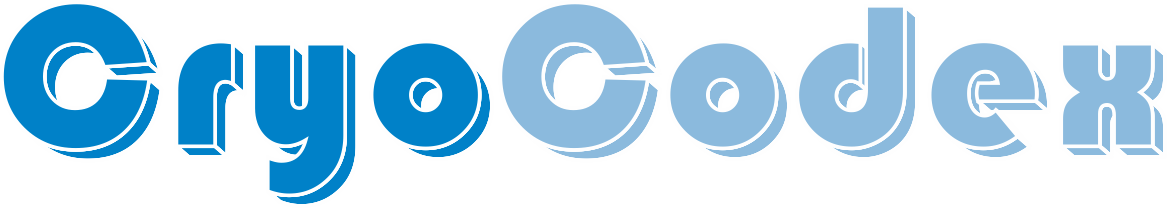

<center>
  <font size="5"><b>Cryo-EM map enhancement · Local quality estimation · Molecular mask prediction</b></font>
  <br><br>
  <font size="4">Bin Cheng · <a href="https://yanglab.qd.sdu.edu.cn">YangLab</a></font>
</center>

Upload one cryo-EM density map to obtain:

<table width="100%" border="0" bgcolor="#FFFFFF" cellspacing="0" cellpadding="0" style="table-layout:fixed">
<tr>
<td width="25%" bgcolor="#FFFFFF" style="border:0;padding:4px"><table width="100%" border="0" cellspacing="0" cellpadding="8" style="border-collapse:separate;border-spacing:0"><tr><td bgcolor="#173E68" align="center" valign="middle" height="64" style="background:#173E68;border:0;border-radius:12px"><font color="#FFFFFF" size="3"><b>Enhanced map</b></font></td></tr></table></td>
<td width="25%" bgcolor="#FFFFFF" style="border:0;padding:4px"><table width="100%" border="0" cellspacing="0" cellpadding="8" style="border-collapse:separate;border-spacing:0"><tr><td bgcolor="#286DA5" align="center" valign="middle" height="64" style="background:#286DA5;border:0;border-radius:12px"><font color="#FFFFFF" size="3"><b>Input map local quality</b></font></td></tr></table></td>
<td width="25%" bgcolor="#FFFFFF" style="border:0;padding:4px"><table width="100%" border="0" cellspacing="0" cellpadding="8" style="border-collapse:separate;border-spacing:0"><tr><td bgcolor="#70ABD0" align="center" valign="middle" height="64" style="background:#70ABD0;border:0;border-radius:12px"><font color="#123B5B" size="3"><b>Enhanced map local quality</b></font></td></tr></table></td>
<td width="25%" bgcolor="#FFFFFF" style="border:0;padding:4px"><table width="100%" border="0" cellspacing="0" cellpadding="8" style="border-collapse:separate;border-spacing:0"><tr><td bgcolor="#C9E3F2" align="center" valign="middle" height="64" style="background:#C9E3F2;border:0;border-radius:12px"><font color="#173E68" size="3"><b>Predicted molecular mask</b></font></td></tr></table></td>
</tr>
</table>

## Quick start

> **RUN IN ORDER — ONE CELL AT A TIME**
>
> ### Step 1 → Step 2 → Step 3 → Step 4 → Step 5
>
> Wait for each step to finish and complete its confirmation before continuing.  
> ⚠️ **Do not use Runtime → Run all.**



---

For more detailed usage information, read the **Usage Guide at the bottom of this notebook**. [Read Usage Guide ↓](#scrollTo=cryocodex-guide)

[Report an issue](https://github.com/YangLab-SDU/CryoCodex/issues) &nbsp; · &nbsp; [Local installation & source code](https://github.com/YangLab-SDU/CryoCodex)


In [ ]:
#@title # Step 1: Set up environment { display-mode: "form" }
#@markdown <div style="font:14px/1.6 Arial,sans-serif;color:#42627E;background:linear-gradient(110deg,#EDF5FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:10px;padding:12px 16px;margin:8px 0">Prepare the environment and model weights once per runtime.</div>
import html, importlib.util, json, os, pathlib, shutil, subprocess, sys, threading, uuid, time, urllib.request
from google.colab import files, output
from IPython.display import display, HTML

REPO = pathlib.Path('/content/CryoCodex')
ENV = pathlib.Path('/content/cryocodex_env')
SHARED = pathlib.Path('/content/.cryocodex')
ASSETS = SHARED / 'assets'
ASSETS.mkdir(parents=True, exist_ok=True)
PY = str(ENV / 'bin/python')
WEIGHTS = REPO / 'model_state_dicts/CryoCodex.pth'
REVISION = '6d1a7401ef9b477d75d5f4cc63b95bda4d46b993'
ENV_READY = False
os.environ.update({
    'UV_CACHE_DIR': str(SHARED / 'cache/uv'),
    'UV_PYTHON_INSTALL_DIR': str(SHARED / 'python'),
    'PIP_CACHE_DIR': str(SHARED / 'cache/pip'),
    'TORCH_HOME': str(SHARED / 'cache/torch'),
    'XDG_CACHE_HOME': str(SHARED / 'cache'),
    'TMPDIR': str(SHARED / 'tmp'),
})
(SHARED / 'tmp').mkdir(exist_ok=True)

def panel(title, message):
    return HTML(f'<div style="max-width:960px;padding:18px 20px;background:linear-gradient(110deg,#F4F8FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:12px;font:14px/1.6 Arial,sans-serif;color:#42627E;overflow-wrap:anywhere"><div style="font-size:18px;font-weight:700;color:#174C78;margin-bottom:6px">{html.escape(title)}</div>{html.escape(str(message))}</div>')

def run(command, **kwargs):
    return subprocess.run([str(x) for x in command], check=True, **kwargs)

def ensure_environment():
    global ENV_READY
    required = [pathlib.Path(PY), REPO / 'predict.py', WEIGHTS, ASSETS / 'runner.py']
    missing = [str(p) for p in required if not p.is_file() or p.stat().st_size == 0]
    if missing:
        ENV_READY = False
        raise RuntimeError('Run step 1 to restore missing environment files: ' + ', '.join(missing))
    check = subprocess.run([PY, '-c', 'import torch,numpy,scipy,numba,mrcfile,timm; assert torch.cuda.is_available(), "No CUDA GPU available"'], capture_output=True, text=True)
    ENV_READY = check.returncode == 0
    if not ENV_READY:
        raise RuntimeError('Environment validation failed. Run step 1 to repair it. ' + check.stderr[-1200:])

def setup_environment():
    """Fixed isolated Python 3.11 installation, with one continuously updating status panel."""
    global ENV_READY
    log_path = SHARED / 'setup.log'
    view = display(HTML(''), display_id=True)
    tasks = [
        'GPU availability', 'Install setup tools', 'Prepare Python 3.11',
        'Create environment', 'Clone repository', 'Select tested revision',
        'Install PyTorch / CUDA', 'Install project requirements',
        'Check dependencies', 'Download model weights',
        'Check GPU inference', 'Finalize environment'
    ]
    total = len(tasks)
    completed = 0
    started = time.monotonic()
    history = []
    current_started = started

    def progress(label, detail='', active=True, download=None, failed=False):
        # The numeric percentage is an estimate while a command is running.
        # Completed stages alone determine the guaranteed minimum percentage.
        elapsed_stage = time.monotonic() - current_started
        partial = (0.90 * (1 - pow(2.718281828, -elapsed_stage / 45))) if active else 0
        if download is not None:
            partial = max(partial, min(.97, download))
        percentage = min(100, (completed + partial) * 100 / total)
        elapsed = int(time.monotonic() - started)
        status = 'FAILED' if failed else ('RUNNING' if active else 'COMPLETE')
        color = '#C0392B' if failed else '#2F80C0'
        recent = ''.join('<div style="padding:3px 0">'+html.escape(x)+'</div>' for x in history[-5:])
        # A single progress bar. The striped animation shows activity without another bar.
        motion = ('background-image:linear-gradient(110deg,transparent 0%,rgba(255,255,255,.35) 50%,transparent 100%);'
                  'background-size:75px 100%;animation:ccmove 1.0s linear infinite;') if active else ''
        view.update(HTML(f"""<style>@keyframes ccmove{{from{{background-position:-75px 0}}to{{background-position:75px 0}}}}</style>
        <div style="max-width:960px;background:linear-gradient(110deg,#F4F8FF,#F0FAFA);border:1px solid #BFD9EA;border-radius:10px;padding:20px;font:15px Arial;color:#1B3A5F">
          <div style="font-size:22px;font-weight:700;color:#245A8D">CryoCodex · Environment setup</div>
          <div style="margin:12px 0 5px;font-weight:700">{html.escape(label)}</div>
          <div style="min-height:24px;color:#52799A;overflow-wrap:anywhere">{html.escape(str(detail)[-260:])}</div>
          <div style="display:flex;justify-content:space-between;margin:12px 0 6px;font-size:13px;color:#52799A">
            <span>Stage {min(completed+1,total)} / {total} · {status} · {elapsed}s elapsed · current stage {int(elapsed_stage)}s</span>
            <b>{percentage:.1f}%</b></div>
          <div style="height:16px;background:#E5F0F8;border-radius:8px;overflow:hidden"><div style="height:100%;width:{percentage:.2f}%;background-color:{color};{motion}transition:width .25s"></div></div>
          <div style="margin-top:5px;color:#52799A;font-size:12px">Estimated overall progress; installation completion is not linear.</div>
          <div style="margin-top:12px;padding-top:8px;border-top:1px solid #E5F0F8;color:#52799A;font-size:13px">{recent}</div>
          <div style="margin-top:8px;font-size:12px;color:#52799A">Full log: {html.escape(str(log_path))}</div>
        </div>"""))

    def finish(label, detail='Done'):
        nonlocal completed, current_started
        completed += 1
        history.append('✓ ' + label + ' · ' + detail)
        current_started = time.monotonic()
        progress(label, detail, active=False)

    def command(label, args):
        nonlocal current_started
        current_started = time.monotonic()
        args = list(map(str, args))
        progress(label, 'Starting: ' + ' '.join(args)[-180:])
        with log_path.open('a', encoding='utf-8') as log:
            log.write('\n$ '+' '.join(args)+'\n'); log.flush()
            start_offset = log.tell()
            proc = subprocess.Popen(args, stdout=log, stderr=subprocess.STDOUT)
            try:
                while proc.poll() is None:
                    time.sleep(.25)
                    with log_path.open('rb') as reader:
                        reader.seek(max(start_offset, log_path.stat().st_size - 3500))
                        lines = reader.read().decode('utf-8','replace').replace('\r','\n').splitlines()
                    detail = next((x.strip() for x in reversed(lines) if x.strip()), 'Running; waiting for package manager output...')
                    progress(label, detail)
                if proc.returncode:
                    raise RuntimeError(f'{label} failed (exit {proc.returncode}). See {log_path}')
            except BaseException:
                if proc.poll() is None:
                    proc.terminate(); proc.wait()
                raise

    try:
        if not shutil.which('nvidia-smi'):
            raise RuntimeError('Choose Runtime → Change runtime type → GPU.')
        command('Checking GPU availability', ['nvidia-smi', '-L'])
        finish(tasks[0], 'GPU found')

        # Use uv's fixed-version isolated environment rather than package-by-package inspection.
        if not shutil.which('uv'):
            command('Installing uv', [sys.executable, '-m', 'pip', 'install', '-q', 'uv'])
        uv = shutil.which('uv')
        if not uv:
            raise RuntimeError('uv was not found after installation')
        finish(tasks[1], 'uv ready')

        if not pathlib.Path(PY).is_file():
            command('Preparing Python 3.11', [uv, 'python', 'install', '3.11'])
            finish(tasks[2], 'Python 3.11 prepared')
            command('Creating isolated environment', [uv, 'venv', '--python', '3.11', str(ENV)])
            finish(tasks[3], 'Dedicated environment created')
        else:
            finish(tasks[2], 'Already available')
            finish(tasks[3], 'Existing dedicated environment')

        if not (REPO / '.git').is_dir():
            if REPO.exists() and any(REPO.iterdir()):
                raise RuntimeError(f'{REPO} exists but is not a Git checkout')
            command('Cloning CryoCodex', ['git', 'clone', '--progress', 'https://github.com/YangLab-SDU/CryoCodex.git', str(REPO)])
        finish(tasks[4], 'Source ready')

        # Deterministic pinned version. Avoid recloning the same repository.
        head = subprocess.run(['git','-C',str(REPO),'rev-parse','HEAD'],capture_output=True,text=True,check=True).stdout.strip()
        if head != REVISION:
            dirty = subprocess.run(['git','-C',str(REPO),'status','--porcelain'],capture_output=True,text=True,check=True).stdout.strip()
            if dirty:
                raise RuntimeError('Repository has local edits; refusing to discard them')
            command('Selecting tested source revision', ['git','-C',str(REPO),'checkout',REVISION])
        finish(tasks[5], 'Pinned revision ready')

        # Pin installs in one pass; uv will reuse its wheel cache when possible.
        command('Installing PyTorch 2.5.1 + CUDA 12.4',
                [uv, 'pip', 'install', '--python', PY, 'torch==2.5.1', 'torchvision==0.20.1',
                 '--index-url', 'https://download.pytorch.org/whl/cu124'])
        finish(tasks[6], 'GPU PyTorch installed')

        command('Installing requirements.txt',
                [uv, 'pip', 'install', '--python', PY, '-r', str(REPO/'requirements.txt')])
        finish(tasks[7], 'Dependencies installed')

        command('Checking package imports', [PY, '-c',
                'import torch,torchvision,numpy,scipy,numba,mrcfile,timm; print(torch.__version__)'])
        finish(tasks[8], 'Imports successful')

        WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
        if not WEIGHTS.is_file() or WEIGHTS.stat().st_size == 0:
            part = WEIGHTS.with_suffix('.pth.part')
            current_started = time.monotonic()
            for attempt in range(3):
                try:
                    with urllib.request.urlopen('https://yanglab.qd.sdu.edu.cn/CryoCodex/CryoCodex.pth', timeout=60) as response, part.open('wb') as dest:
                        size = int(response.headers.get('Content-Length') or 0)
                        received = 0
                        while True:
                            chunk = response.read(1024 * 1024)
                            if not chunk: break
                            dest.write(chunk)
                            received += len(chunk)
                            detail = f'Downloaded {received/1048576:.1f} MB'
                            if size: detail += f' / {size/1048576:.1f} MB ({100*received/size:.1f}%)'
                            progress('Downloading model weights', detail,
                                     download=min(.97,received/size) if size else None)
                        if not received or (size and received != size):
                            raise IOError('Model weights download incomplete')
                    part.replace(WEIGHTS)
                    break
                except Exception:
                    part.unlink(missing_ok=True)
                    if attempt == 2: raise
                    progress('Retrying model download', f'Attempt {attempt+2}/3')
        finish(tasks[9], f'{WEIGHTS.stat().st_size/1048576:.1f} MB available')

        command('Validating CUDA execution', [PY,'-c',
                'import torch; assert torch.cuda.is_available(); x=torch.ones((2,2),device="cuda"); assert float(x.sum())==4; print(torch.cuda.get_device_name(0))'])
        finish(tasks[10], 'GPU test passed')
        (SHARED / 'environment.json').write_text(json.dumps({'revision':REVISION,'python':PY,'torch':'2.5.1'}),encoding='utf-8')
        ENV_READY = True
        finish(tasks[11], 'Configuration saved')
        progress('Ready — continue to Step 2', 'Setup completed successfully.', active=False)
    except Exception as exc:
        ENV_READY = False
        progress('Setup interrupted', str(exc), active=False, failed=True)
        raise RuntimeError(f'{exc} Installation log: {log_path}') from exc

QC_HTML = r'''<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>CryoCodex Molecular Region QC</title>
<style>
:root{
  --bg:#f5f7fa; --card:#fff; --ink:#17212b; --muted:#527999; --line:#d0d5dd;
  --blue:#245A8D; --blue2:#2F80C0; --highlight:#4d9ddf; --strong:#2688d9;
}
*{box-sizing:border-box}
body{
  margin:0;background:var(--bg);color:var(--ink);
  font-family:Inter,ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
}
.wrap{max-width:1440px;margin:24px auto;padding:0 20px 40px}
h1{font-size:26px;margin:0 0 4px}
.sub{margin:0 0 16px;color:var(--muted);line-height:1.5}
.card{
  background:var(--card);border:1px solid #eaecf0;border-radius:14px;padding:16px;
  box-shadow:0 1px 2px rgba(16,24,40,.05);margin-bottom:14px
}
.toolbar{display:flex;gap:12px;flex-wrap:wrap;align-items:end}
.field{min-width:260px;flex:1}
label{display:block;font-size:13px;font-weight:700;margin-bottom:7px}
input[type=file]{
  width:100%;padding:9px;border:1px solid var(--line);border-radius:9px;background:#fff
}
button{
  border:0;border-radius:9px;padding:10px 14px;font-weight:750;cursor:pointer;
  background:var(--blue);color:white
}
button.secondary{background:#eef4f8;color:#17324d}
button.warn{background:#e4f0fa;color:#154a75;border:1px solid #a8d0f0}
button:disabled{opacity:.45;cursor:not-allowed}
.status{
  margin-top:12px;padding:10px 12px;border-radius:9px;background:#f2f4f7;color:#344054;
  font-size:13px;white-space:pre-wrap
}
.status.ok{background:#edf5fc;color:#134269}
.status.bad{background:#e9f3fb;color:#154a75}
.stats{
  display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:9px;margin-top:12px
}
.stat{border:1px solid #eaecf0;border-radius:10px;padding:9px;background:#fafbfc}
.stat b{display:block;font-size:11px;color:var(--muted);margin-bottom:3px}
.stat span{font-size:13px;font-variant-numeric:tabular-nums}
.controls{
  display:grid;grid-template-columns:minmax(280px,1.5fr) minmax(240px,1fr) auto;gap:16px;align-items:end
}
input[type=range]{width:100%}
.help{font-size:12px;color:var(--muted);line-height:1.5;margin-top:7px}
.views{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:14px}
.view{
  position:relative;border:1px solid #e4e7ec;border-radius:12px;background:#0b0f14;
  overflow:hidden;min-width:0
}
.viewhead{
  background:white;padding:9px 11px;border-bottom:1px solid #e4e7ec;
  display:flex;justify-content:space-between;align-items:center
}
.viewhead b{font-size:14px}
.viewhead span{font-size:11px;color:var(--muted)}
.canvas-wrap{position:relative;width:100%;background:black}
canvas{display:block;width:100%;height:auto;touch-action:none;cursor:crosshair}
.axis-x{
  position:absolute;left:10px;right:10px;bottom:7px;display:flex;justify-content:space-between;
  color:#fff;font-size:11px;pointer-events:none;text-shadow:0 1px 3px #000
}
.axis-y{
  position:absolute;top:9px;bottom:9px;left:7px;display:flex;flex-direction:column;
  justify-content:space-between;color:#fff;font-size:11px;pointer-events:none;text-shadow:0 1px 3px #000
}
.bounds{
  display:grid;grid-template-columns:repeat(6,minmax(90px,1fr));gap:8px;margin-top:12px
}
.bound{
  border:1px solid #e4e7ec;border-radius:10px;padding:9px;background:#f8fafb;text-align:center
}
.bound b{display:block;font-size:11px;color:var(--muted);margin-bottom:3px}
.bound span{font-size:16px;font-weight:800;font-variant-numeric:tabular-nums}
.footerrow{display:flex;gap:9px;flex-wrap:wrap;margin-top:12px}
.tip{
  margin-top:10px;padding:9px 11px;border-left:3px solid var(--highlight);background:#eff6fc;
  font-size:13px;line-height:1.5
}
kbd{background:#f2f4f7;border:1px solid #d0d5dd;border-bottom-width:2px;border-radius:5px;padding:1px 5px;font-size:11px}
@media(max-width:1000px){
  .views{grid-template-columns:1fr}
  .stats{grid-template-columns:repeat(2,1fr)}
  .controls{grid-template-columns:1fr}
  .bounds{grid-template-columns:repeat(3,1fr)}
}
</style>

<style>
body, button, input, select {font-family:Arial,sans-serif;}
:root {--bg:#F1F7FC;--card:#FFFFFF;--panel:#F1F7FC;--panel2:#E5F0F8;--ink:#1B3A5F;--text:#1B3A5F;--muted:#52799A;--line:#BFD9EA;--blue:#2F80C0;--blue2:#6BAED6;--accent:#2F80C0;--highlight:#6BAED6;}
h1,h2,h3 {color:#1B3A5F;}
.card,.map-card,.settings-box,.status,.stat,.bound,.empty {border:1px solid #BFD9EA;border-radius:6px;box-shadow:none;}
.card,.map-card,.settings-box {background:#FFFFFF;}
.header,.viewhead {background:#F1F7FC;}
button,.file-btn {background:#2F80C0;color:#FFFFFF;border:1px solid #2F80C0;border-radius:6px;font-weight:600;}
button:hover,.file-btn:hover {background:#245A8D;color:#FFFFFF;transform:none;}
button.secondary,button.warn,button.danger {background:#E5F0F8;color:#1B3A5F;border-color:#BFD9EA;}
.status,.status.ok,.status.bad {background:#E5F0F8;color:#1B3A5F;border-left:4px solid #2F80C0;}
input,select {accent-color:#2F80C0;}
input:focus,select:focus {outline:2px solid #6BAED6;outline-offset:1px;}
button:disabled {opacity:.45;cursor:not-allowed;}
#sidebar {background:#F1F7FC;box-shadow:none;}
.small-note,.help,.subtitle {color:#52799A;}
</style>
<style>
body {font-size:16px;}
label,.subtitle,.help,.status,.small-note,.ctrl-row label,.render-row label {font-size:14px;}
button,.file-btn,input[type=number],input[type=text],select {font-size:14px;}
.map-name {font-size:16px;}
.map-meta,.stat b,.bound b,.viewhead span {font-size:13px;}
#app {grid-template-columns:minmax(0,1fr) 420px;}
@media(max-width:900px){#app{grid-template-columns:1fr;grid-template-rows:minmax(0,1fr) 360px;}}
</style>
<style>
html,body{margin:0;width:100%;height:100%;overflow:hidden;font-family:Arial,sans-serif;color:#1B3A5F;background:#F1F7FC}
*{box-sizing:border-box}
.wrap{width:100%;height:100%;max-width:none;margin:0;padding:12px;display:grid;grid-template-rows:auto minmax(0,1fr) auto;gap:10px}
.crop-header{min-width:0}.crop-title{font-size:22px;font-weight:700;color:#1565C0;margin-bottom:8px}
.crop-controls{display:grid;grid-template-columns:auto minmax(100px,1fr) auto;align-items:center;gap:12px}
.crop-controls label{font-size:15px;margin:0}.crop-controls label span{font-size:13px;color:#52799A}
input[type=range]{accent-color:#1565C0;width:100%;margin:0}
#status{font-size:13px;line-height:1.3;margin-top:7px;white-space:nowrap;overflow:hidden;text-overflow:ellipsis;padding:0;border:0;background:transparent}
.views{display:grid;grid-template-columns:repeat(3,minmax(0,1fr));gap:10px;min-height:0}
.view{min-width:0;min-height:0;display:flex;flex-direction:column;border:1px solid #BFD9EA;border-radius:8px;overflow:hidden;background:#071625}
.viewhead{padding:7px 10px;flex-shrink:0;display:flex;justify-content:space-between;background:white}.viewhead b{font-size:16px}.viewhead span{font-size:12px}
.canvas-wrap{flex:1;min-height:0;display:flex;align-items:center;justify-content:center;position:relative;overflow:hidden}
canvas{display:block;width:auto;height:auto;max-width:100%;max-height:100%;touch-action:none;cursor:crosshair}
.crop-bottom{background:white;border:1px solid #BFD9EA;border-radius:8px;padding:10px 12px}
.bounds{display:flex;flex-wrap:wrap;gap:8px 24px;margin:0 0 8px;font-size:14px}
.confirm-row{display:flex;align-items:center;justify-content:space-between;gap:12px}#colabMsg{font-size:14px;line-height:1.3}
button{border-radius:7px;font-size:15px;padding:9px 12px;cursor:pointer}#sendColab{background:#1565C0;color:white;font-size:18px;font-weight:700;padding:12px 22px;white-space:nowrap;border:1px solid #0D47A1}
button:disabled{opacity:.45;cursor:not-allowed}
@media(max-width:650px){.wrap{padding:8px;gap:6px}.crop-title{font-size:18px;margin-bottom:4px}.crop-controls{grid-template-columns:minmax(0,1fr) auto;gap:4px 8px}.crop-controls label{grid-column:1/-1}.crop-controls label span{margin-left:8px}.views{gap:5px}.viewhead{padding:5px}.viewhead span{display:none}.crop-bottom{padding:8px}.bounds{gap:6px 14px;font-size:12px}.confirm-row{gap:8px}#colabMsg{font-size:12px}#sendColab{font-size:16px;padding:10px 14px}}
</style>
<style>
body {font-family:Arial,sans-serif;color:#24435F;}
.header,.crop-top {background:linear-gradient(110deg,#EDF5FF,#EAF7F7);border-bottom:1px solid #D5E4F0;}
#sidebar {background:#F4F7FC;}
.map-card,.view,.crop-bottom {border:1px solid #D5E4F0;border-radius:12px;box-shadow:0 3px 12px rgba(25,65,105,.05);}
.map-head,.viewhead {background:linear-gradient(110deg,#F0F6FF,#F1FAFA);}
button,.file-btn {border-radius:8px;}
input,select {accent-color:#2878BA;}
#legend {border-left:3px solid #319DAB;border-radius:10px;}
#legendBar {border-radius:6px;}
</style>
</head>
<body>
<div class="wrap">
  <header class="crop-header">
    <div class="crop-title">Review crop</div>
    <div class="crop-controls">
      <label for="tail">Density threshold <span id="tailText">99.900th percentile</span></label>
      <input id="tail" type="range" min="2" max="4" value="3" step="0.025" disabled title="Higher threshold shows less density">
      <button id="fullBox" class="secondary" disabled>Reset to full map</button>
    </div>
    <div id="status" role="status" aria-live="polite" style="padding:10px 14px;margin-top:8px;border-radius:8px;background:#FFF3D6;color:#785414;font-weight:700">Please wait · Loading prepared map…</div>
  </header>
  <div class="views">
<div class="view"><div class="viewhead"><b>XY</b><span>Drag blue edges</span></div><div class="canvas-wrap"><canvas id="xy"></canvas></div></div>
<div class="view"><div class="viewhead"><b>XZ</b><span>Drag blue edges</span></div><div class="canvas-wrap"><canvas id="xz"></canvas></div></div>
<div class="view"><div class="viewhead"><b>YZ</b><span>Drag blue edges</span></div><div class="canvas-wrap"><canvas id="yz"></canvas></div></div>
  </div>
  <div class="crop-bottom">
    <div class="bounds"><div>X: <span id="xmin">—</span> – <span id="xmax">—</span></div><div>Y: <span id="ymin">—</span> – <span id="ymax">—</span></div><div>Z: <span id="zmin">—</span> – <span id="zmax">—</span></div></div>
    <div class="confirm-row"><span id="colabMsg">Adjust the crop, then confirm.</span><button id="sendColab" disabled>Confirm crop</button></div>
  </div>
</div>
<script>
"use strict";

const $ = id => document.getElementById(id);

let volume = null;           // {nx,ny,nz, mode, data, mapc,mapr,maps, dims:[X,Y,Z]}
let projections = null;      // XY/XZ/YZ MIPs in physical X/Y/Z
let currentThreshold = NaN;
let tailFraction = 0.001;
let bounds = null;           // {xmin,xmax,ymin,ymax,zmin,zmax}, inclusive voxel indices
let cropConfirmed = false;
let thresholdPending = false;
let drag = null;
let hover = {xy:null,xz:null,yz:null};

const VIEW_DEF = {
  xy: {u:"x", v:"y", umin:"xmin", umax:"xmax", vmin:"ymin", vmax:"ymax"},
  xz: {u:"x", v:"z", umin:"xmin", umax:"xmax", vmin:"zmin", vmax:"zmax"},
  yz: {u:"y", v:"z", umin:"ymin", umax:"ymax", vmin:"zmin", vmax:"zmax"}
};

function plausible(nx,ny,nz,mode){
  return nx>0&&ny>0&&nz>0&&nx<20000&&ny<20000&&nz<20000&&[0,1,2,6].includes(mode);
}

function parseMRC(buffer){
  if(buffer.byteLength<1024) throw new Error("File is smaller than 1024 bytes; invalid MRC/MAP.");
  const dv=new DataView(buffer);
  let le=true;
  let nx=dv.getInt32(0,true), ny=dv.getInt32(4,true), nz=dv.getInt32(8,true), mode=dv.getInt32(12,true);
  if(!plausible(nx,ny,nz,mode)){
    le=false;
    nx=dv.getInt32(0,false); ny=dv.getInt32(4,false); nz=dv.getInt32(8,false); mode=dv.getInt32(12,false);
  }
  if(!plausible(nx,ny,nz,mode)) throw new Error("Invalid MRC header or unsupported mode.");

  let mapc=dv.getInt32(64,le), mapr=dv.getInt32(68,le), maps=dv.getInt32(72,le);
  if(![1,2,3].includes(mapc)||![1,2,3].includes(mapr)||![1,2,3].includes(maps)||new Set([mapc,mapr,maps]).size!==3){
    mapc=1; mapr=2; maps=3;
  }

  const nsymbt=Math.max(0,dv.getInt32(92,le));
  const offset=1024+nsymbt;
  const n=nx*ny*nz;
  let bpv=0, getter=null;
  if(mode===0){bpv=1;getter=o=>dv.getInt8(o)}
  if(mode===1){bpv=2;getter=o=>dv.getInt16(o,le)}
  if(mode===2){bpv=4;getter=o=>dv.getFloat32(o,le)}
  if(mode===6){bpv=2;getter=o=>dv.getUint16(o,le)}
  if(offset+n*bpv>buffer.byteLength) throw new Error("MRC header and data size do not match.");

  let data;
  if(mode===2 && le && offset%4===0){
    data=new Float32Array(buffer,offset,n);
  }else{
    data=new Float32Array(n);
    let p=offset;
    for(let i=0;i<n;i++,p+=bpv) data[i]=getter(p);
  }

  const dims=[0,0,0];
  dims[mapc-1]=nx; dims[mapr-1]=ny; dims[maps-1]=nz;
  return {nx,ny,nz,mode,data,mapc,mapr,maps,dims,le};
}

function physicalXYZ(c,r,s){
  const q=[0,0,0];
  q[volume.mapc-1]=c;
  q[volume.mapr-1]=r;
  q[volume.maps-1]=s;
  return q;
}

async function computeProjections(vol){
  const [X,Y,Z]=vol.dims;
  const xy=new Float32Array(X*Y); xy.fill(-Infinity);
  const xz=new Float32Array(X*Z); xz.fill(-Infinity);
  const yz=new Float32Array(Y*Z); yz.fill(-Infinity);

  let idx=0;
  for(let s=0;s<vol.nz;s++){
    for(let r=0;r<vol.ny;r++){
      for(let c=0;c<vol.nx;c++,idx++){
        const val=vol.data[idx];
        if(!Number.isFinite(val)) continue;
        const q=[0,0,0];
        q[vol.mapc-1]=c; q[vol.mapr-1]=r; q[vol.maps-1]=s;
        const x=q[0],y=q[1],z=q[2];
        const ixy=y*X+x, ixz=z*X+x, iyz=z*Y+y;
        if(val>xy[ixy]) xy[ixy]=val;
        if(val>xz[ixz]) xz[ixz]=val;
        if(val>yz[iyz]) yz[iyz]=val;
      }
    }
    if((s&7)===0){
      $("status").textContent=`Computing projections... ${Math.round(100*(s+1)/vol.nz)}%`;
      await new Promise(r=>setTimeout(r,0));
    }
  }
  return {
    xy:{w:X,h:Y,a:xy},
    xz:{w:X,h:Z,a:xz},
    yz:{w:Y,h:Z,a:yz}
  };
}
function quantileThreshold(data, tail){
  let min=Infinity,max=-Infinity,n=0;
  for(let i=0;i<data.length;i++){
    const v=data[i];
    if(Number.isFinite(v)){
      if(v<min)min=v;if(v>max)max=v;n++;
    }
  }
  if(!n) throw new Error("Map contains no finite voxel values.");
  if(min===max) return min;

  const rank=Math.max(0,Math.min(n-1,Math.floor((1-tail)*n)));
  const B=32768;
  const hist=new Uint32Array(B);
  const scale=(B-1)/(max-min);

  for(let i=0;i<data.length;i++){
    const v=data[i]; if(!Number.isFinite(v)) continue;
    let b=Math.floor((v-min)*scale);
    if(b<0)b=0; else if(b>=B)b=B-1;
    hist[b]++;
  }

  let cum=0,targetBin=0,before=0;
  for(let b=0;b<B;b++){
    const next=cum+hist[b];
    if(rank<next){targetBin=b;before=cum;break}
    cum=next;
  }
  const lo=min+targetBin/scale;
  const hi=min+(targetBin+1)/scale;
  const vals=[];
  for(let i=0;i<data.length;i++){
    const v=data[i]; if(!Number.isFinite(v)) continue;
    const inside=(targetBin===B-1)?(v>=lo&&v<=max):(v>=lo&&v<hi);
    if(inside) vals.push(v);
  }
  vals.sort((a,b)=>a-b);
  const local=Math.max(0,Math.min(vals.length-1,rank-before));
  return vals[local];
}

function updateThreshold(){
  tailFraction=Math.pow(10,-Number($("tail").value));
  currentThreshold=sessionInfo.thresholds[Math.round((Number($("tail").value)-2)/0.025)];
  $("tailText").textContent=`≥ ${currentThreshold.toPrecision(5)} · ${(100*(1-tailFraction)).toFixed(3)}th percentile`;


}

function fullBounds(){
  const [X,Y,Z]=volume.dims;
  bounds={xmin:0,xmax:X-1,ymin:0,ymax:Y-1,zmin:0,zmax:Z-1};
  syncBoundsUI(); renderAll();
}

function autoBoundsFromThreshold(padFrac=0.025){
  const [X,Y,Z]=volume.dims;
  let xmin=X,xmax=-1,ymin=Y,ymax=-1,zmin=Z,zmax=-1;
  let found=0;
  // Projection maxima retain the exact full-volume bounding box at any threshold.
  for(let y=0;y<Y;y++) for(let x=0;x<X;x++){
    if(projections.xy.a[y*X+x]>=currentThreshold){
      xmin=Math.min(xmin,x);xmax=Math.max(xmax,x);
      ymin=Math.min(ymin,y);ymax=Math.max(ymax,y);found++;
    }
  }
  for(let z=0;z<Z;z++) for(let x=0;x<X;x++){
    if(projections.xz.a[z*X+x]>=currentThreshold){zmin=Math.min(zmin,z);zmax=Math.max(zmax,z);}
  }
  if(!found){ fullBounds(); return; }

  const px=Math.max(2,Math.round(X*padFrac));
  const py=Math.max(2,Math.round(Y*padFrac));
  const pz=Math.max(2,Math.round(Z*padFrac));
  bounds={
    xmin:Math.max(0,xmin-px),xmax:Math.min(X-1,xmax+px),
    ymin:Math.max(0,ymin-py),ymax:Math.min(Y-1,ymax+py),
    zmin:Math.max(0,zmin-pz),zmax:Math.min(Z-1,zmax+pz)
  };
  syncBoundsUI();renderAll();
}

function syncBoundsUI(){
  if(sessionInfo && !cropConfirmed && !thresholdPending){document.getElementById('sendColab').disabled=false;document.getElementById('colabMsg').textContent='Crop changed. Click Confirm crop to save these bounds.';}
  if(!bounds)return;
  for(const k of ["xmin","xmax","ymin","ymax","zmin","zmax"]) $(k).textContent=bounds[k];
}

function percentileOfProjection(a,p){
  const vals=[];
  const step=Math.max(1,Math.floor(a.length/250000));
  for(let i=0;i<a.length;i+=step) if(Number.isFinite(a[i])) vals.push(a[i]);
  vals.sort((x,y)=>x-y);
  if(!vals.length)return 1;
  return vals[Math.max(0,Math.min(vals.length-1,Math.floor(p*(vals.length-1))))];
}

function draw(viewName){
  if(!projections||!bounds)return;
  const canvas=$(viewName), ctx=canvas.getContext("2d");
  const proj=projections[viewName], def=VIEW_DEF[viewName];
  const {w,h,a}=proj;
  canvas.width=w; canvas.height=h;
  const hi=Math.max(currentThreshold+1e-12, (proj.displayHigh ??= percentileOfProjection(a,0.995)));
  const img=ctx.createImageData(w,h);
  for(let y=0;y<h;y++){
    const srcY=h-1-y; // Display +Y/+Z upward
    for(let x=0;x<w;x++){
      const v=a[srcY*w+x];
      let g=0;
      if(Number.isFinite(v)&&v>=currentThreshold){
        const t=Math.max(0,Math.min(1,(v-currentThreshold)/(hi-currentThreshold)));
        g=Math.round(55+200*Math.sqrt(t));
      }
      const p=4*(y*w+x);
      img.data[p]=g;img.data[p+1]=g;img.data[p+2]=g;img.data[p+3]=255;
    }
  }
  ctx.putImageData(img,0,0);
  const u0=bounds[def.umin], u1=bounds[def.umax];
  const v0=bounds[def.vmin], v1=bounds[def.vmax];
  const left=u0, right=u1;
  const top=(h-1)-v1, bottom=(h-1)-v0;

  ctx.save();
  ctx.fillStyle="rgba(0,0,0,.34)";
  ctx.fillRect(0,0,w,Math.max(0,top));
  ctx.fillRect(0,bottom,w,h-bottom);
  ctx.fillRect(0,top,left,bottom-top);
  ctx.fillRect(right,top,w-right,bottom-top);
  ctx.restore();

  const active=hover[viewName];
  function line(x1,y1,x2,y2,key){
    ctx.save();
    ctx.strokeStyle=(active===key)?"#ffffff":"#4d9ddf";
    ctx.lineWidth=(active===key)?Math.max(2,w/180):Math.max(1.4,w/240);
    ctx.setLineDash(active===key?[]:[Math.max(3,w/120),Math.max(2,w/180)]);
    ctx.beginPath();ctx.moveTo(x1,y1);ctx.lineTo(x2,y2);ctx.stroke();ctx.restore();
  }
  line(left,top,left,bottom,def.umin);
  line(right,top,right,bottom,def.umax);
  line(left,bottom,right,bottom,def.vmin);
  line(left,top,right,top,def.vmax);
}

function renderAll(){
  if(!volume||!projections||!bounds)return;
  draw("xy");draw("xz");draw("yz");
  syncBoundsUI();
}

function pointerToVoxel(canvas,ev){
  const rect=canvas.getBoundingClientRect();
  const x=(ev.clientX-rect.left)/rect.width*canvas.width;
  const y=(ev.clientY-rect.top)/rect.height*canvas.height;
  return {x,y};
}

function hitTest(viewName,ev){
  if(!bounds)return null;
  const canvas=$(viewName), def=VIEW_DEF[viewName];
  const p=pointerToVoxel(canvas,ev);
  const h=canvas.height;
  const lines=[
    [def.umin,bounds[def.umin],"x"],
    [def.umax,bounds[def.umax],"x"],
    [def.vmin,(h-1)-bounds[def.vmin],"y"],
    [def.vmax,(h-1)-bounds[def.vmax],"y"]
  ];
  const rect=canvas.getBoundingClientRect();
  const tolX=11/rect.width*canvas.width;
  const tolY=11/rect.height*canvas.height;
  let best=null,bestD=Infinity;
  for(const [key,pos,axis] of lines){
    const d=Math.abs((axis==="x"?p.x:p.y)-pos);
    const tol=axis==="x"?tolX:tolY;
    if(d<=tol && d<bestD){best={key,axis};bestD=d}
  }
  return best;
}

function limitBound(key,val){
  const [X,Y,Z]=volume.dims;
  val=Math.round(val);
  if(key==="xmin") return Math.max(0,Math.min(bounds.xmax-1,val));
  if(key==="xmax") return Math.max(bounds.xmin+1,Math.min(X-1,val));
  if(key==="ymin") return Math.max(0,Math.min(bounds.ymax-1,val));
  if(key==="ymax") return Math.max(bounds.ymin+1,Math.min(Y-1,val));
  if(key==="zmin") return Math.max(0,Math.min(bounds.zmax-1,val));
  if(key==="zmax") return Math.max(bounds.zmin+1,Math.min(Z-1,val));
  return val;
}

for(const viewName of ["xy","xz","yz"]){
  const canvas=$(viewName);
  canvas.addEventListener("pointermove",ev=>{
    if(!volume)return;
    if(drag && drag.view===viewName){
      const p=pointerToVoxel(canvas,ev);
      let val;
      if(drag.axis==="x") val=p.x;
      else val=(canvas.height-1)-p.y;
      bounds[drag.key]=limitBound(drag.key,val);
      hover[viewName]=drag.key;
      renderAll();
      return;
    }
    const hit=hitTest(viewName,ev);
    hover[viewName]=hit?.key??null;
    canvas.style.cursor=hit?(hit.axis==="x"?"ew-resize":"ns-resize"):"crosshair";
    draw(viewName);
  });
  canvas.addEventListener("pointerleave",()=>{
    if(!drag){hover[viewName]=null;draw(viewName)}
  });
  canvas.addEventListener("pointerdown",ev=>{
    const hit=hitTest(viewName,ev);
    if(!hit)return;
    canvas.setPointerCapture(ev.pointerId);
    drag={view:viewName,key:hit.key,axis:hit.axis,pointerId:ev.pointerId};
  });
  canvas.addEventListener("pointerup",ev=>{
    if(drag&&drag.pointerId===ev.pointerId){
      drag=null;
      try{canvas.releasePointerCapture(ev.pointerId)}catch(_){}
      renderAll();
    }
  });

  canvas.addEventListener("dblclick",()=>{
    const proj=projections[viewName], def=VIEW_DEF[viewName];
    let umin=proj.w,umax=-1,vmin=proj.h,vmax=-1;
    for(let v=0;v<proj.h;v++){
      for(let u=0;u<proj.w;u++){
        if(proj.a[v*proj.w+u] >= currentThreshold){
          if(u<umin)umin=u;if(u>umax)umax=u;
          if(v<vmin)vmin=v;if(v>vmax)vmax=v;
        }
      }
    }
    if(umax>=0){
      const pu=Math.max(2,Math.round(proj.w*.025));
      const pv=Math.max(2,Math.round(proj.h*.025));
      bounds[def.umin]=limitBound(def.umin,Math.max(0,umin-pu));
      bounds[def.umax]=limitBound(def.umax,Math.min(proj.w-1,umax+pu));
      bounds[def.vmin]=limitBound(def.vmin,Math.max(0,vmin-pv));
      bounds[def.vmax]=limitBound(def.vmax,Math.min(proj.h-1,vmax+pv));
      renderAll();
    }
  });
}

async function loadPreview(){
  $("status").textContent="Please wait · Downloading compact crop projections…";
  const response=await fetch('api/projections');
  if(!response.ok) throw Error('Apply settings again to prepare the crop preview.');
  const buffer=await response.arrayBuffer();
  const [Z,Y,X]=sessionInfo.shape;
  const expected=4*(X*Y+X*Z+Y*Z);
  if(buffer.byteLength!==expected) throw Error('Incomplete crop preview. Apply settings again.');
  const values=new Float32Array(buffer);
  volume={dims:[X,Y,Z]};
  projections={xy:{w:X,h:Y,a:values.subarray(0,X*Y)},
               xz:{w:X,h:Z,a:values.subarray(X*Y,X*Y+X*Z)},
               yz:{w:Y,h:Z,a:values.subarray(X*Y+X*Z)}};
  $("tail").value="3";
  updateThreshold();
  bounds={};
  for(const a of 'xyz'){bounds[a+'min']=sessionInfo.bounds[a][0];bounds[a+'max']=sessionInfo.bounds[a][1];}
  syncBoundsUI();renderAll();
  $("tail").disabled=false;$("fullBox").disabled=false;
  $("status").textContent="Ready · Higher threshold shows less density. Drag blue edges to crop.";
  $("status").className="status ok";
}

let tailTimer=null;
$("tail").addEventListener("input",()=>{
  if(!volume || cropConfirmed)return;
  thresholdPending=true;
  $("sendColab").disabled=true;
  const t=Math.pow(10,-Number($("tail").value));
  $("tailText").textContent=`${(100*(1-t)).toFixed(3)}th percentile · updating…`;
  clearTimeout(tailTimer);
  tailTimer=setTimeout(()=>{
    $("status").className="status";
    $("status").textContent="Updating display threshold...";
    setTimeout(()=>{
      try{
        updateThreshold();
        autoBoundsFromThreshold();
        thresholdPending=false;
        $("sendColab").disabled=false;
        $("status").className="status ok";
        $("status").textContent="Threshold updated. Review the blue crop box and confirm.";
      }catch(err){
        $("status").className="status bad";$("status").textContent=err.message;
      }
    },0);
  },180);
});

$("fullBox").addEventListener("click",()=>fullBounds());

function boundsObject(){
  const [X,Y,Z]=volume.dims;
  return {
    xmin:bounds.xmin,xmax:bounds.xmax,
    ymin:bounds.ymin,ymax:bounds.ymax,
    zmin:bounds.zmin,zmax:bounds.zmax,
    size_x:bounds.xmax-bounds.xmin+1,
    size_y:bounds.ymax-bounds.ymin+1,
    size_z:bounds.zmax-bounds.zmin+1,
    map_size:{x:X,y:Y,z:Z},
    display_threshold:currentThreshold,
    display_top_fraction:tailFraction
  };
}



let sessionInfo=null;
document.getElementById('sendColab').onclick=async()=>{
  try{
    if(!volume || !projections || !sessionInfo || thresholdPending) throw Error('Wait for the preview to finish updating.');
    if(cropConfirmed) return;
    $('sendColab').disabled=true;
    $('sendColab').textContent='Saving…';
    const result=await fetch('api/bounds',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify({...boundsObject(),session:sessionInfo.session})});
    const data=await result.json(); if(!result.ok) throw Error(data.error);
    cropConfirmed=true;
    document.querySelector('.views').style.pointerEvents='none';
    $('tail').disabled=true; $('fullBox').disabled=true;
    $('sendColab').textContent='Crop confirmed';
    document.getElementById('sendColab').disabled=true;
    document.getElementById('colabMsg').textContent='Crop confirmed. Run step 4 to start inference.';
  }catch(e){$('sendColab').disabled=false;$('sendColab').textContent='Confirm crop';document.getElementById('colabMsg').textContent=e.message;}
};
(async()=>{
  try{
    sessionInfo=await (await fetch('api/session')).json();
    await loadPreview();
    document.getElementById('colabMsg').textContent='Drag blue edges or adjust the threshold, then confirm.';
    document.getElementById('sendColab').disabled=false;
  }catch(e){document.getElementById('colabMsg').textContent=e.message;}
})();

</script>
</body>
</html>
'''
VIEWER_HTML = r'''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Cryo-EM Density Viewer</title>
  <script type="importmap">
  {
    "imports": {
      "three": "https://cdn.jsdelivr.net/npm/three@0.180.0/build/three.module.js",
      "three/addons/": "https://cdn.jsdelivr.net/npm/three@0.180.0/examples/jsm/"
    }
  }
  </script>
  <style>
    :root {
      --bg: #9fb8cc;
      --panel: #dfe7ee;
      --panel2: #d7dde3;
      --line: #acc1d2;
      --text: #1f2a33;
      --muted: #4d718f;
      --accent: #2F80C0;
      --accent2: #6BAED6;
      --danger: #2b7dc0;
      --shadow: 0 16px 40px rgba(0,0,0,.16);
    }
    * { box-sizing: border-box; }
    html, body { width:100%; height:100%; margin:0; overflow:hidden; background:var(--bg); color:var(--text); font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif; }
    #app { display:grid; grid-template-columns:minmax(0,1fr) 370px; height:100%; }
    #viewport { position:relative; min-width:0; background: radial-gradient(circle at 35% 25%, #cbd8e3 0%, #b2c6d6 48%, #9fb8cc 100%); }
    canvas { display:block; width:100%; height:100%; }
    #sidebar { border-left:1px solid var(--line); background:linear-gradient(180deg,#eef1f4,#dde3e9); overflow:auto; box-shadow:-8px 0 28px rgba(0,0,0,.08); }
    .header { position:sticky; top:0; z-index:4; background:rgba(236,240,244,.96); backdrop-filter:blur(12px); padding:18px 18px 14px; border-bottom:1px solid var(--line); }
    .title { font-size:16px; font-weight:750; letter-spacing:.2px; }
    .subtitle { font-size:12px; color:var(--muted); margin-top:5px; line-height:1.5; }
    .toolbar { display:flex; gap:8px; margin-top:13px; flex-wrap:wrap; }
    .render-row { display:grid; grid-template-columns:92px minmax(0,1fr); gap:10px; align-items:center; margin-top:10px; }
    .render-row label { color:var(--muted); font-size:11px; }
    button, .file-btn { border:1px solid #9fb0c2; background:#f7f9fb; color:#1f2a33; padding:8px 11px; border-radius:8px; font-size:12px; cursor:pointer; transition:.15s ease; }
    button:hover, .file-btn:hover { background:#edf3f8; border-color:#7fa2c0; transform:translateY(-1px); }
    button.secondary { background:#eef2f6; border-color:#b4c0cb; }
    button.danger { border-color:#324f67; background:#19252e; color:#bad9f3; }
    input[type=file] { display:none; }
    #mapList { padding:12px; }
    .empty { color:var(--muted); font-size:13px; line-height:1.65; padding:24px 18px; border:1px dashed #b8c3cf; border-radius:12px; text-align:center; margin:8px 0; background:rgba(255,255,255,.35); }
    .map-card { background:linear-gradient(180deg,#f8fafb,#edf2f6); border:1px solid #c2ccd5; border-radius:12px; margin-bottom:10px; overflow:hidden; box-shadow:0 7px 22px rgba(0,0,0,.08); }
    .map-head { display:grid; grid-template-columns:28px 18px minmax(0,1fr) 28px; gap:8px; align-items:center; padding:11px 11px 9px; border-bottom:1px solid #d1d9e0; }
    .eye { width:18px; height:18px; accent-color:#4ca1df; cursor:pointer; }
    .swatch { width:15px; height:15px; border-radius:50%; border:1px solid rgba(255,255,255,.35); }
    .map-name { font-size:13px; font-weight:680; overflow:hidden; text-overflow:ellipsis; white-space:nowrap; }
    .map-meta { font-size:10.5px; color:var(--muted); margin-top:3px; }
    .trash { width:28px; height:28px; padding:0; display:grid; place-items:center; border-radius:7px; background:transparent; border:1px solid transparent; color:#557e9f; }
    .trash:hover { color:#2b7dc0; border-color:#aec3d4; background:#e8f0f7; }
    .controls { padding:10px 11px 12px; display:grid; gap:10px; }
    .ctrl-row { display:grid; grid-template-columns:80px minmax(0,1fr) 72px; gap:8px; align-items:center; }
    .ctrl-row.two { grid-template-columns:80px minmax(0,1fr); }
    .ctrl-row label { color:#4d718f; font-size:11px; }
    input[type=range] { width:100%; accent-color:var(--accent); }
    input[type=number], input[type=text], select { width:100%; border:1px solid #b9c5cf; background:#ffffff; color:#1f2a33; border-radius:7px; padding:6px 7px; font-size:11px; outline:none; }
    input[type=number]:focus, input[type=text]:focus, select:focus { border-color:#4b87b4; box-shadow:0 0 0 2px rgba(75,135,180,.12); }
    input[type=color] { width:100%; height:29px; border:1px solid #b9c5cf; border-radius:7px; background:#ffffff; padding:2px 3px; }
    .color-block { border-top:1px dashed #cad3db; padding-top:10px; display:grid; gap:9px; }
    .small-note { color:#5983a5; font-size:10px; line-height:1.45; }
    .palette-wrap { position:relative; }
    .palette-preview { height:9px; border-radius:999px; margin-top:6px; border:1px solid rgba(255,255,255,.12); }
    #hud { position:absolute; top:14px; left:14px; z-index:2; display:flex; gap:8px; align-items:center; flex-wrap:wrap; pointer-events:none; }
    .pill { pointer-events:auto; padding:7px 9px; background:rgba(250,252,254,.82); border:1px solid rgba(120,132,145,.35); backdrop-filter: blur(10px); border-radius:8px; font-size:11px; color:#42515f; box-shadow:var(--shadow); }
    #dropHint { position:absolute; inset:18px; z-index:5; border:2px dashed rgba(47,128,192,.55); background:rgba(235,241,247,.72); backdrop-filter: blur(4px); display:none; place-items:center; border-radius:18px; color:#28425d; font-size:18px; font-weight:700; }
    #status { max-width:520px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap; }
    #legend { position:absolute; left:18px; bottom:18px; z-index:3; min-width:310px; background:rgba(248,250,252,.92); border:1px solid rgba(140,152,165,.45); box-shadow:var(--shadow); border-radius:11px; padding:10px 12px 11px; display:none; backdrop-filter:blur(10px); }
    #legendTitle { font-size:11px; color:#31404d; margin-bottom:7px; max-width:420px; overflow:hidden; text-overflow:ellipsis; white-space:nowrap; }
    #legendBar { height:14px; border-radius:4px; border:1px solid rgba(255,255,255,.16); }
    #legendTicks { display:flex; justify-content:space-between; color:#4f7493; font-size:10px; margin-top:5px; }
    .section-title { color:#5f88a9; font-size:10px; letter-spacing:.08em; text-transform:uppercase; padding:4px 2px 8px; }
    .settings { padding:0 12px 14px; }
    .settings-box { border:1px solid #c2ccd5; border-radius:10px; padding:10px; background:#f8fafc; }
    .settings-row { display:grid; grid-template-columns:130px minmax(0,1fr); gap:10px; align-items:center; }
    .settings-row label { font-size:11px; color:#aeb9c7; }
    @media (max-width: 850px) {
      #app { grid-template-columns:1fr; grid-template-rows:minmax(0,1fr) 330px; }
      #sidebar { border-left:none; border-top:1px solid var(--line); }
    }
  </style>

<style>
body, button, input, select {font-family:Arial,sans-serif;}
:root {--bg:#F1F7FC;--card:#FFFFFF;--panel:#F1F7FC;--panel2:#E5F0F8;--ink:#1B3A5F;--text:#1B3A5F;--muted:#52799A;--line:#BFD9EA;--blue:#2F80C0;--blue2:#6BAED6;--accent:#2F80C0;--highlight:#6BAED6;}
h1,h2,h3 {color:#1B3A5F;}
.card,.map-card,.settings-box,.status,.stat,.bound,.empty {border:1px solid #BFD9EA;border-radius:6px;box-shadow:none;}
.card,.map-card,.settings-box {background:#FFFFFF;}
.header,.viewhead {background:#F1F7FC;}
button,.file-btn {background:#2F80C0;color:#FFFFFF;border:1px solid #2F80C0;border-radius:6px;font-weight:600;}
button:hover,.file-btn:hover {background:#245A8D;color:#FFFFFF;transform:none;}
button.secondary,button.warn,button.danger {background:#E5F0F8;color:#1B3A5F;border-color:#BFD9EA;}
.status,.status.ok,.status.bad {background:#E5F0F8;color:#1B3A5F;border-left:4px solid #2F80C0;}
input,select {accent-color:#2F80C0;}
input:focus,select:focus {outline:2px solid #6BAED6;outline-offset:1px;}
button:disabled {opacity:.45;cursor:not-allowed;}
#sidebar {background:#F1F7FC;box-shadow:none;}
.small-note,.help,.subtitle {color:#52799A;}
</style>
<style>
body {font-size:16px;}
label,.subtitle,.help,.status,.small-note,.ctrl-row label,.render-row label {font-size:14px;}
button,.file-btn,input[type=number],input[type=text],select {font-size:14px;}
.map-name {font-size:16px;}
.map-meta,.stat b,.bound b,.viewhead span {font-size:13px;}
#app {grid-template-columns:minmax(0,1fr) 420px;}
@media(max-width:900px){#app{grid-template-columns:1fr;grid-template-rows:minmax(0,1fr) 360px;}}
</style>
<style>
html,body {width:100%;height:100%;min-width:0;font-size:clamp(13px,1.1vw,16px);}
#app {width:100%;height:100%;min-height:0;grid-template-columns:minmax(0,1fr) clamp(280px,32vw,380px);grid-template-rows:minmax(0,1fr);}
#viewport {min-width:0;min-height:0;overflow:hidden;}
#viewport canvas {display:block;max-width:100%;}
#sidebar {min-width:0;min-height:0;overflow-y:auto;overflow-x:hidden;overscroll-behavior:contain;scrollbar-gutter:stable;}
.header {padding:clamp(10px,1.5vw,18px);}
.title {font-size:clamp(17px,1.5vw,22px);}
.subtitle,.help,.small-note {font-size:clamp(12px,1vw,14px);line-height:1.5;overflow-wrap:anywhere;}
.toolbar {display:flex;flex-wrap:wrap;gap:6px;}
button,.file-btn,input[type=number],input[type=text],select {font-size:clamp(13px,1vw,15px);min-width:0;}
.file-btn {display:inline-flex;align-items:center;}
.map-head {grid-template-columns:24px 16px minmax(0,1fr) 26px;gap:6px;}
.map-name {font-size:clamp(13px,1.1vw,16px);overflow-wrap:anywhere;white-space:normal;}
.map-meta {font-size:12px;}
.ctrl-row {grid-template-columns:82px minmax(0,1fr) 64px;gap:6px;}
.ctrl-row.two {grid-template-columns:82px minmax(0,1fr);}
.ctrl-row label,.render-row label {font-size:clamp(12px,1vw,14px);}
.ctrl-row > *,.palette-wrap {min-width:0;max-width:100%;}
#legend {position:static;min-width:0;max-width:none;width:auto;margin:10px 12px;padding:12px;box-shadow:none;backdrop-filter:none;background:#FFFFFF;}
#legendTitle {font-size:13px;max-width:none;white-space:normal;overflow-wrap:anywhere;text-overflow:clip;line-height:1.4;}
#legendTicks {font-size:12px;}
#legendStops {grid-template-columns:repeat(auto-fit,minmax(38px,1fr))!important;font-size:12px!important;}
#hud {top:8px;left:8px;right:8px;gap:5px;}
.pill {font-size:clamp(11px,.9vw,13px);max-width:100%;box-shadow:none;}
#status {max-width:100%;}
#dropHint {font-size:clamp(14px,1.5vw,20px);padding:10px;text-align:center;}
@media(max-width:1100px),(max-height:650px){.header{position:static}.subtitle{margin-top:4px}.header{padding:10px}#mapList{padding:8px}.controls{padding:8px}}
@media(max-width:700px){#app{grid-template-columns:minmax(0,1fr);grid-template-rows:minmax(180px,52%) minmax(0,1fr)}#sidebar{border-left:0;border-top:1px solid #BFD9EA}#hud .pill:first-child{display:none}.header .subtitle{display:none}.header .toolbar{margin-top:6px}.header .render-row{margin-top:6px}}
@media(max-height:450px) and (min-width:701px){#hud .pill:first-child{display:none}}
</style>
<style>
body {font-family:Arial,sans-serif;color:#24435F;}
.header,.crop-top {background:linear-gradient(110deg,#EDF5FF,#EAF7F7);border-bottom:1px solid #D5E4F0;}
#sidebar {background:#F4F7FC;}
.map-card,.view,.crop-bottom {border:1px solid #D5E4F0;border-radius:12px;box-shadow:0 3px 12px rgba(25,65,105,.05);}
.map-head,.viewhead {background:linear-gradient(110deg,#F0F6FF,#F1FAFA);}
button,.file-btn {border-radius:8px;}
input,select {accent-color:#2878BA;}
#legend {border-left:3px solid #319DAB;border-radius:10px;}
#legendBar {border-radius:6px;}
</style>
</head>
<body>
<div id="app">
  <div id="viewport">
    <div id="hud">
      <div class="pill">Left drag: rotate · Right drag: pan · Scroll: zoom</div>
      <div class="pill" id="status">Load an .mrc or .map file</div>
    </div>

    <div id="dropHint">Drop files to load density maps</div>
  </div>

  <aside id="sidebar">
    <div class="header">
      <div class="title">Cryo-EM Density Viewer</div>
      <div class="subtitle">Full resolution · Color by map</div>
      <div class="toolbar">
        <label class="file-btn">＋ Add maps<input id="fileInput" type="file" accept=".mrc,.map,.ccp4" multiple></label>
        <button id="fitBtn" class="secondary">Fit view</button>
        <button id="resetBtn" class="secondary">Reset camera</button>
      </div>
      <div class="render-row">
        <label for="renderMode">Display mode</label>
        <select id="renderMode">
          <option value="soft" selected>soft</option>
          <option value="lit">lighted</option>
        </select>
      </div>
    </div>

    <div id="legend">
      <div id="legendTitle"></div>
      <div id="legendBar"></div>
      <div id="legendTicks"><span id="legendMin"></span><span id="legendMid"></span><span id="legendMax"></span></div>
    </div>

    <div id="mapList">
      <div class="empty" id="emptyState">Drop or select MRC/CCP4 maps.<br>Each map has independent display controls. Full resolution is preserved.</div>
    </div>
  </aside>
</div>

<script type="module">
import * as THREE from 'three';
import { TrackballControls } from 'three/addons/controls/TrackballControls.js';

const viewport = document.getElementById('viewport');
const fileInput = document.getElementById('fileInput');
const mapListEl = document.getElementById('mapList');
const statusEl = document.getElementById('status');
const fitBtn = document.getElementById('fitBtn');
const resetBtn = document.getElementById('resetBtn');
const renderModeEl = document.getElementById('renderMode');
const dropHint = document.getElementById('dropHint');
const legend = document.getElementById('legend');
const legendTitle = document.getElementById('legendTitle');
const legendBar = document.getElementById('legendBar');
const legendMin = document.getElementById('legendMin');
const legendMid = document.getElementById('legendMid');
const legendMax = document.getElementById('legendMax');

const DEFAULT_PALETTE = '#1B3A5F:#245A8D:#2F80C0:#6BAED6:#BFD9EA:#7F7F7F:#C9B458:#FEE191:#F9B233:#FC8E59:#F04438:#DC3223:#8B0000';
const BASE_COLORS = ['#2F80C0','#6BAED6','#1B3A5F','#A9CFE8','#245A8D','#BFD9EA','#458EC4','#87BDDF'];

const renderer = new THREE.WebGLRenderer({ antialias:true, alpha:false, preserveDrawingBuffer:true });
renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));
renderer.outputColorSpace = THREE.SRGBColorSpace;
renderer.toneMapping = THREE.ACESFilmicToneMapping;
renderer.toneMappingExposure = 1.0;
renderer.setClearColor(0xd6e8f5, 1);
viewport.prepend(renderer.domElement);

const scene = new THREE.Scene();
const camera = new THREE.PerspectiveCamera(45, 1, 0.01, 100000);
camera.position.set(120, 100, 140);
const controls = new TrackballControls(camera, renderer.domElement);
controls.noRotate = false;
controls.noPan = false;
controls.noZoom = false;
controls.staticMoving = false;
controls.dynamicDampingFactor = 0.18;
controls.rotateSpeed = 4.2;
controls.zoomSpeed = 1.25;
controls.panSpeed = 0.9;
controls.keys = ['KeyA', 'KeyS', 'KeyD'];

scene.background = new THREE.Color(0xd6e8f5);

const lightRigSoft = new THREE.Group();
const softAmbient = new THREE.AmbientLight(0xffffff, 2.3);
const softHemi = new THREE.HemisphereLight(0xf7f9fb, 0xc2c8cf, 1.6);
const softKey = new THREE.DirectionalLight(0xffffff, 0.45); softKey.position.set(1.2, 1.5, 2.0);
lightRigSoft.add(softAmbient, softHemi, softKey);
scene.add(lightRigSoft);

const lightRigLit = new THREE.Group();
const litAmbient = new THREE.AmbientLight(0xffffff, 0.75);
const litHemi = new THREE.HemisphereLight(0xffffff, 0xb7bec6, 0.95);
const litKey = new THREE.DirectionalLight(0xffffff, 1.65); litKey.position.set(1.5, 1.8, 2.2);
const litFill = new THREE.DirectionalLight(0xe6ebf0, 0.8); litFill.position.set(-1.8, 0.9, 1.0);
const litRim = new THREE.DirectionalLight(0xd5dce3, 0.55); litRim.position.set(-2.0, -1.0, 1.1);
lightRigLit.add(litAmbient, litHemi, litKey, litFill, litRim);
scene.add(lightRigLit);

let renderMode = 'soft';

const root = new THREE.Group();
scene.add(root);

let maps = [];
let nextId = 1;
let sceneCenter = new THREE.Vector3(0,0,0);
let sceneCenterInitialized = false;
applyRenderMode();

function resize() {
  const w = viewport.clientWidth, h = viewport.clientHeight;
  renderer.setSize(w,h,false);
  camera.aspect = w / Math.max(1,h);
  camera.updateProjectionMatrix();
  if (controls.handleResize) controls.handleResize();
}
window.addEventListener('resize', resize);
resize();

function animate(){
  requestAnimationFrame(animate);
  controls.update();
  renderer.render(scene,camera);
}
animate();

function setStatus(s){ statusEl.textContent = s; }
function fmt(v){
  if (!Number.isFinite(v)) return '—';
  const av = Math.abs(v);
  if ((av > 0 && av < 1e-3) || av >= 1e4) return v.toExponential(3);
  return v.toFixed(av < 1 ? 4 : av < 100 ? 3 : 2);
}
function clamp(v,a,b){ return Math.max(a, Math.min(b,v)); }
function lerp(a,b,t){ return a + (b-a)*t; }
function debounce(fn, ms=120){ let t; return (...args)=>{ clearTimeout(t); t=setTimeout(()=>fn(...args),ms); }; }

function percentileFromSample(data, q, maxSamples=200000){
  const n = data.length;
  const step = Math.max(1, Math.floor(n/maxSamples));
  const arr=[];
  for(let i=0;i<n;i+=step){ const v=data[i]; if(Number.isFinite(v)) arr.push(v); }
  arr.sort((a,b)=>a-b);
  if(!arr.length) return 0;
  const pos=(arr.length-1)*q;
  const lo=Math.floor(pos), hi=Math.ceil(pos);
  return lo===hi?arr[lo]:lerp(arr[lo],arr[hi],pos-lo);
}

function parseMRC(buffer, name){
  const dv = new DataView(buffer);
  let little = true;
  let nx=dv.getInt32(0,true), ny=dv.getInt32(4,true), nz=dv.getInt32(8,true);
  const plausible=(x,y,z)=>x>0&&y>0&&z>0&&x<100000&&y<100000&&z<100000;
  if(!plausible(nx,ny,nz)){
    little=false; nx=dv.getInt32(0,false); ny=dv.getInt32(4,false); nz=dv.getInt32(8,false);
  }
  if(!plausible(nx,ny,nz)) throw new Error('Invalid MRC/CCP4 header.');
  const i32=o=>dv.getInt32(o,little), f32=o=>dv.getFloat32(o,little);
  const mode=i32(12);
  const nxstart=i32(16), nystart=i32(20), nzstart=i32(24);
  const mx=Math.max(1,i32(28)||nx), my=Math.max(1,i32(32)||ny), mz=Math.max(1,i32(36)||nz);
  const cella=[f32(40),f32(44),f32(48)];
  let mapc=i32(64)||1, mapr=i32(68)||2, mapsAxis=i32(72)||3;
  if(![1,2,3].includes(mapc)||![1,2,3].includes(mapr)||![1,2,3].includes(mapsAxis)){ mapc=1; mapr=2; mapsAxis=3; }
  const dmin=f32(76), dmax=f32(80), dmean=f32(84);
  const nsymbt=Math.max(0,i32(92));
  const origin=[f32(196),f32(200),f32(204)];
  const offset=1024+nsymbt;
  const count=nx*ny*nz;
  let values;
  if(mode===2){
    if(little) values=new Float32Array(buffer,offset,count);
    else { values=new Float32Array(count); for(let i=0;i<count;i++) values[i]=dv.getFloat32(offset+i*4,false); }
  } else if(mode===1){
    values=new Float32Array(count); for(let i=0;i<count;i++) values[i]=dv.getInt16(offset+i*2,little);
  } else if(mode===0){
    values=new Float32Array(count); for(let i=0;i<count;i++) values[i]=dv.getInt8(offset+i);
  } else if(mode===6){
    values=new Float32Array(count); for(let i=0;i<count;i++) values[i]=dv.getUint16(offset+i*2,little);
  } else {
    throw new Error(`Unsupported MRC mode ${mode}; supported modes: 0, 1, 2, 6.`);
  }
  const spacing=[
    cella[0]>0?cella[0]/mx:1,
    cella[1]>0?cella[1]/my:1,
    cella[2]>0?cella[2]/mz:1
  ];
  const startsCRS=[nxstart,nystart,nzstart];
  const axisForCRS=[mapc-1,mapr-1,mapsAxis-1];
  const base=[0,0,0];
  const hasOrigin=origin.some(v=>Number.isFinite(v)&&Math.abs(v)>1e-7);
  if(hasOrigin){ base[0]=origin[0]; base[1]=origin[1]; base[2]=origin[2]; }
  else {
    for(let a=0;a<3;a++) base[axisForCRS[a]]=startsCRS[a]*spacing[axisForCRS[a]];
  }
  // Scan every voxel: header statistics and sampled percentiles may miss extrema.
  let globalMin=Infinity, globalMax=-Infinity;
  for(let i=0;i<values.length;i++){
    const value=values[i];
    if(!Number.isFinite(value)) continue;
    if(value<globalMin) globalMin=value;
    if(value>globalMax) globalMax=value;
  }
  if(!Number.isFinite(globalMin)) throw new Error('Map contains no finite voxel values.');
  const stats={min:globalMin,max:globalMax,mean:Number.isFinite(dmean)?dmean:0};
  const p001=percentileFromSample(values,0.001), p999=percentileFromSample(values,0.999);
  const threshold=percentileFromSample(values,0.995);
  return {name,nx,ny,nz,mode,values,spacing,axisForCRS,base,stats,p001,p999,threshold};
}

function crsToWorld(vol,c,r,s){
  const idx=[0,0,0];
  idx[vol.axisForCRS[0]]=c;
  idx[vol.axisForCRS[1]]=r;
  idx[vol.axisForCRS[2]]=s;
  return [
    vol.base[0]+idx[0]*vol.spacing[0],
    vol.base[1]+idx[1]*vol.spacing[1],
    vol.base[2]+idx[2]*vol.spacing[2]
  ];
}
function worldToCRS(vol,x,y,z){
  const idx=[(x-vol.base[0])/vol.spacing[0],(y-vol.base[1])/vol.spacing[1],(z-vol.base[2])/vol.spacing[2]];
  const crs=[0,0,0];
  crs[0]=idx[vol.axisForCRS[0]];
  crs[1]=idx[vol.axisForCRS[1]];
  crs[2]=idx[vol.axisForCRS[2]];
  return crs;
}
function sampleTrilinear(vol,x,y,z){
  const [c,r,s]=worldToCRS(vol,x,y,z);
  if(c<0||r<0||s<0||c>vol.nx-1||r>vol.ny-1||s>vol.nz-1) return NaN;
  const c0=Math.floor(c),r0=Math.floor(r),s0=Math.floor(s);
  const c1=Math.min(c0+1,vol.nx-1),r1=Math.min(r0+1,vol.ny-1),s1=Math.min(s0+1,vol.nz-1);
  const tx=c-c0,ty=r-r0,tz=s-s0;
  const at=(cc,rr,ss)=>vol.values[(ss*vol.ny+rr)*vol.nx+cc];
  const a00=lerp(at(c0,r0,s0),at(c1,r0,s0),tx);
  const a10=lerp(at(c0,r1,s0),at(c1,r1,s0),tx);
  const a01=lerp(at(c0,r0,s1),at(c1,r0,s1),tx);
  const a11=lerp(at(c0,r1,s1),at(c1,r1,s1),tx);
  const b0=lerp(a00,a10,ty), b1=lerp(a01,a11,ty);
  return lerp(b0,b1,tz);
}

const cubeCorners=[[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,1],[1,0,1],[1,1,1],[0,1,1]];
const tets=[[0,5,1,6],[0,1,2,6],[0,2,3,6],[0,3,7,6],[0,7,4,6],[0,4,5,6]];

function buildIsoGeometry(vol, iso){
  const step=1;
  const gx=Math.floor((vol.nx-1)/step)+1, gy=Math.floor((vol.ny-1)/step)+1, gz=Math.floor((vol.nz-1)/step)+1;
  const grid=new Float32Array(gx*gy*gz);
  const gi=(x,y,z)=>(z*gy+y)*gx+x;
  for(let z=0;z<gz;z++){
    const s=Math.min(z*step,vol.nz-1);
    for(let y=0;y<gy;y++){
      const r=Math.min(y*step,vol.ny-1);
      let base=(s*vol.ny+r)*vol.nx;
      for(let x=0;x<gx;x++) grid[gi(x,y,z)]=vol.values[base+Math.min(x*step,vol.nx-1)];
    }
  }
  const positions=[];
  const worlds=[];
  const p=new Array(8), v=new Float32Array(8);
  const interp=(a,b,va,vb)=>{
    let t=(iso-va)/(vb-va);
    if(!Number.isFinite(t)) t=.5;
    t=clamp(t,0,1);
    return [lerp(a[0],b[0],t),lerp(a[1],b[1],t),lerp(a[2],b[2],t)];
  };
  const pushTri=(a,b,c)=>{
    for(const q of [a,b,c]){
      positions.push(q[0]-sceneCenter.x,q[1]-sceneCenter.y,q[2]-sceneCenter.z);
      worlds.push(q[0],q[1],q[2]);
    }
  };
  for(let z=0;z<gz-1;z++){
    for(let y=0;y<gy-1;y++){
      for(let x=0;x<gx-1;x++){
        let below=0,above=0;
        for(let k=0;k<8;k++){
          const cc=Math.min((x+cubeCorners[k][0])*step,vol.nx-1);
          const rr=Math.min((y+cubeCorners[k][1])*step,vol.ny-1);
          const ss=Math.min((z+cubeCorners[k][2])*step,vol.nz-1);
          v[k]=grid[gi(x+cubeCorners[k][0],y+cubeCorners[k][1],z+cubeCorners[k][2])];
          p[k]=crsToWorld(vol,cc,rr,ss);
          if(v[k]>=iso) above++; else below++;
        }
        if(above===0||below===0) continue;
        for(const tet of tets){
          const inside=[],outside=[];
          for(const id of tet) (v[id]>=iso?inside:outside).push(id);
          if(inside.length===0||inside.length===4) continue;
          if(inside.length===1 || inside.length===3){
            const inv=inside.length===3;
            const one=(inv?outside:inside)[0];
            const others=inv?inside:outside;
            const a=interp(p[one],p[others[0]],v[one],v[others[0]]);
            const b=interp(p[one],p[others[1]],v[one],v[others[1]]);
            const c=interp(p[one],p[others[2]],v[one],v[others[2]]);
            if(inv) pushTri(a,c,b); else pushTri(a,b,c);
          } else if(inside.length===2){
            const i0=inside[0],i1=inside[1],o0=outside[0],o1=outside[1];
            const a=interp(p[i0],p[o0],v[i0],v[o0]);
            const b=interp(p[i0],p[o1],v[i0],v[o1]);
            const c=interp(p[i1],p[o0],v[i1],v[o0]);
            const d=interp(p[i1],p[o1],v[i1],v[o1]);
            pushTri(a,b,c); pushTri(b,d,c);
          }
        }
      }
    }
  }
  const geom=new THREE.BufferGeometry();
  geom.setAttribute('position',new THREE.Float32BufferAttribute(positions,3));
  geom.computeVertexNormals();
  geom.computeBoundingSphere();
  geom.userData.worlds=new Float32Array(worlds);
  geom.userData.step=step;
  return geom;
}

function applyRenderMode() {
  lightRigSoft.visible = renderMode === 'soft';
  lightRigLit.visible = renderMode === 'lit';
  for (const m of maps) {
    if (!m.mesh) continue;
    const hadVertexColors = !!m.mesh.geometry.getAttribute('color') && !!m.colorById;
    const oldMat = m.mesh.material;
    const newMat = defaultMaterial(m.baseColor);
    if (hadVertexColors) {
      newMat.vertexColors = true;
      newMat.color.set(0xffffff);
    }
    m.mesh.material = newMat;
    oldMat.dispose();
    updateMaterialState(m);
  }
}

function colorDomainForMap(name,volume){
  const quality=/(?:in_?score|out_?score|quality)(?:\.|$)/i.test(name);
  const lo=volume.stats.min,hi=volume.stats.max;
  return {isQuality:quality,colorDomain:[lo,hi]};
}
function parsePalette(text){
  const parts=text.split(':').map(s=>s.trim()).filter(Boolean);
  const colors=[];
  for(const p of parts){
    try{ colors.push(new THREE.Color(p)); }catch(e){}
  }
  return colors.length>=2?colors:[new THREE.Color('#000000'),new THREE.Color('#ffffff')];
}
function paletteCSS(text){
  const parts=text.split(':').map(s=>s.trim()).filter(Boolean);
  if(parts.length<2) return 'linear-gradient(90deg,#000,#fff)';
  return `linear-gradient(90deg,${parts.join(',')})`;
}
function paletteColor(colors,t,out=new THREE.Color()){
  t=clamp(t,0,1);
  const f=t*(colors.length-1), i=Math.min(colors.length-2,Math.floor(f)), u=f-i;
  return out.copy(colors[i]).lerp(colors[i+1],u);
}

function defaultMaterial(color){
  if (renderMode === 'lit') {
    return new THREE.MeshPhongMaterial({
      color:new THREE.Color(color),
      shininess:28,
      specular:new THREE.Color(0x9ea8b4),
      side:THREE.DoubleSide,
      vertexColors:false
    });
  }
  return new THREE.MeshLambertMaterial({
    color:new THREE.Color(color),
    side:THREE.DoubleSide,
    vertexColors:false
  });
}
function updateMaterialState(m){
  if(!m.mesh) return;
  m.mesh.visible=m.visible;
  const mat=m.mesh.material;
  if(!m.colorById){ mat.vertexColors=false; mat.color.set(m.baseColor); }
  mat.needsUpdate=true;
}

function applyColorSampling(target){
  if(!target.mesh) return;
  const source=maps.find(m=>m.id===target.colorById);
  const geom=target.mesh.geometry;
  if(!source){
    if(target.ui) target.ui.palette.readOnly=false;
    geom.deleteAttribute('color');
    target.mesh.material.vertexColors=false;
    target.mesh.material.color.set(target.baseColor);
    target.mesh.material.needsUpdate=true;
    renderLegend();
    return;
  }
  const worlds=geom.userData.worlds;
  const n=worlds.length/3;
  const vals=new Float32Array(n);
  for(let i=0;i<n;i++){
    vals[i]=sampleTrilinear(source.volume,worlds[i*3],worlds[i*3+1],worlds[i*3+2]);
  }
  const [lo,hi]=source.colorDomain;
  if(source.isQuality){
    target.palette=DEFAULT_PALETTE;
    if(target.ui){target.ui.palette.value=DEFAULT_PALETTE;target.ui.palettePreview.style.background=paletteCSS(DEFAULT_PALETTE);}
  }
  if(target.ui) target.ui.palette.readOnly=source.isQuality;
  target.colorRange=[lo,hi];
  const colors=parsePalette(target.palette);
  const rgb=new Float32Array(n*3);
  const c=new THREE.Color();
  for(let i=0;i<n;i++){
    const val=vals[i];
    const t=Number.isFinite(val)?(hi>lo?(val-lo)/(hi-lo):0.5):0;
    paletteColor(colors,t,c);
    rgb[i*3]=c.r; rgb[i*3+1]=c.g; rgb[i*3+2]=c.b;
  }
  geom.setAttribute('color',new THREE.BufferAttribute(rgb,3));
  target.mesh.material.vertexColors=true;
  target.mesh.material.color.set(0xffffff);
  target.mesh.material.needsUpdate=true;
  renderLegend();
}

function renderLegend(){
  const colored=maps.filter(m=>m.visible && m.mesh && m.colorById);
  if(!colored.length){ legend.style.display='none'; return; }
  const m=colored[colored.length-1];
  const src=maps.find(x=>x.id===m.colorById);
  if(!src){ legend.style.display='none'; return; }
  legend.style.display='block';
  legendTitle.textContent=`${src.name} · full-map range`;
  legendBar.style.background=src.colorDomain[0]===src.colorDomain[1] ? m.palette.split(':')[Math.floor(m.palette.split(':').length/2)] : paletteCSS(m.palette);
  const [lo,hi]=src.colorDomain;
  legendMin.textContent=fmt(lo); legendMid.textContent=fmt((lo+hi)/2); legendMax.textContent=fmt(hi);

}

async function rebuildMap(m, refit=false){
  if(m.mesh){ root.remove(m.mesh); m.mesh.geometry.dispose(); m.mesh.material.dispose(); m.mesh=null; }
  setStatus(`Building surface: ${m.name} ...`);
  await new Promise(r=>setTimeout(r,20));
  const geom=buildIsoGeometry(m.volume,m.threshold);
  const mat=defaultMaterial(m.baseColor);
  m.mesh=new THREE.Mesh(geom,mat);
  m.mesh.name=m.name;
  root.add(m.mesh);
  updateMaterialState(m);
  if(m.colorById) applyColorSampling(m);
  setStatus(`${m.name} · ${geom.attributes.position.count.toLocaleString()} vertices · full resolution`);
  if(refit) fitView();
}

function volumeBounds(vol){
  const pts=[
    crsToWorld(vol,0,0,0), crsToWorld(vol,vol.nx-1,0,0), crsToWorld(vol,0,vol.ny-1,0), crsToWorld(vol,0,0,vol.nz-1),
    crsToWorld(vol,vol.nx-1,vol.ny-1,0), crsToWorld(vol,vol.nx-1,0,vol.nz-1), crsToWorld(vol,0,vol.ny-1,vol.nz-1), crsToWorld(vol,vol.nx-1,vol.ny-1,vol.nz-1)
  ];
  const box=new THREE.Box3(); pts.forEach(p=>box.expandByPoint(new THREE.Vector3(...p))); return box;
}
function fitView(){
  if(!maps.length) return;
  const box=new THREE.Box3();
  for(const m of maps){ if(m.mesh && m.visible) box.expandByObject(m.mesh); }
  if(box.isEmpty()) return;
  const sphere=new THREE.Sphere(); box.getBoundingSphere(sphere);
  const r=Math.max(sphere.radius,1);
  controls.target.copy(sphere.center);
  camera.position.copy(sphere.center).add(new THREE.Vector3(1.25,1.0,1.45).normalize().multiplyScalar(r*3.0));
  camera.near=Math.max(r/1000,.01); camera.far=Math.max(r*20,1000); camera.updateProjectionMatrix();
  controls.update();
}
function resetCamera(){ camera.position.set(120,100,140); controls.target.set(0,0,0); controls.update(); }

function refreshColorSelectors(){
  for(const m of maps){
    if(!m.ui) continue;
    const sel=m.ui.colorBy;
    const current=m.colorById||'';
    sel.innerHTML='<option value="">None · single color</option>' + maps.filter(x=>x.id!==m.id).map(x=>`<option value="${x.id}">${escapeHtml(x.name)}</option>`).join('');
    sel.value=current && maps.some(x=>x.id===current)?String(current):'';
    if(sel.value!==String(current)){ m.colorById=''; if(m.mesh) applyColorSampling(m); }
  }
  renderLegend();
}
function escapeHtml(s){ return s.replace(/[&<>'"]/g,c=>({'&':'&amp;','<':'&lt;','>':'&gt;',"'":'&#39;','"':'&quot;'}[c])); }

function addMapCard(m){
  const emptyStateNow=document.getElementById('emptyState');
  if(emptyStateNow) emptyStateNow.style.display='none';
  const card=document.createElement('div'); card.className='map-card';
  card.innerHTML=`
    <div class="map-head">
      <input class="eye" type="checkbox" checked title="Visible">
      <div class="swatch" style="background:${m.baseColor}"></div>
      <div><div class="map-name" title="${escapeHtml(m.name)}">${escapeHtml(m.name)}</div><div class="map-meta">${m.volume.nx} × ${m.volume.ny} × ${m.volume.nz} · mode ${m.volume.mode}</div></div>
      <button class="trash" title="Remove">×</button>
    </div>
    <div class="controls">
      <div class="ctrl-row"><label>Threshold</label><input class="thr-range" type="range"><input class="thr-num" type="number" step="any"></div>
      <div class="ctrl-row two"><label>Base color</label><input class="base-color" type="color" value="${m.baseColor}"></div>
      <div class="color-block">
        <div class="ctrl-row two"><label>Color by map</label><select class="color-by"></select></div>
        <div class="ctrl-row two"><label>Palette</label><div class="palette-wrap"><input class="palette" type="text" value="${DEFAULT_PALETTE}"><div class="palette-preview"></div></div></div>
        <div class="small-note">Sample the selected map to color this surface.</div>
      </div>
    </div>`;
  mapListEl.appendChild(card);
  const q=s=>card.querySelector(s);
  const eye=q('.eye'),swatch=q('.swatch'),trash=q('.trash'),thrRange=q('.thr-range'),thrNum=q('.thr-num'),baseColor=q('.base-color'),colorBy=q('.color-by'),palette=q('.palette'),palettePreview=q('.palette-preview');
  const lo=m.volume.p001, hi=m.volume.p999>lo?m.volume.p999:m.volume.stats.max;
  thrRange.min=lo; thrRange.max=hi; thrRange.step=(hi-lo)/700 || .001; thrRange.value=clamp(m.threshold,lo,hi);
  thrNum.value=m.threshold;
  palettePreview.style.background=paletteCSS(m.palette);
  m.ui={card,eye,swatch,thrRange,thrNum,baseColor,colorBy,palette,palettePreview};

  const doRebuild=debounce(()=>rebuildMap(m,false),130);
  eye.addEventListener('change',()=>{ m.visible=eye.checked; updateMaterialState(m); renderLegend(); });
  thrRange.addEventListener('input',()=>{ m.threshold=Number(thrRange.value); thrNum.value=m.threshold; setStatus(`${m.name} threshold = ${fmt(m.threshold)}`); doRebuild(); });
  thrNum.addEventListener('change',()=>{ m.threshold=Number(thrNum.value); thrRange.value=clamp(m.threshold,Number(thrRange.min),Number(thrRange.max)); rebuildMap(m,false); });
  baseColor.addEventListener('input',()=>{ m.baseColor=baseColor.value; swatch.style.background=m.baseColor; if(!m.colorById) updateMaterialState(m); });
  colorBy.addEventListener('change',()=>{ m.colorById=colorBy.value?Number(colorBy.value):''; applyColorSampling(m); });
  palette.addEventListener('change',()=>{ m.palette=palette.value; palettePreview.style.background=paletteCSS(m.palette); if(m.colorById) applyColorSampling(m); });
  palette.addEventListener('input',()=>{ palettePreview.style.background=paletteCSS(palette.value); });
  trash.addEventListener('click',()=>removeMap(m.id));
  refreshColorSelectors();
}

function removeMap(id){
  const idx=maps.findIndex(m=>m.id===id); if(idx<0) return;
  const m=maps[idx];
  if(m.mesh){ root.remove(m.mesh); m.mesh.geometry.dispose(); m.mesh.material.dispose(); }
  m.ui?.card.remove(); maps.splice(idx,1);
  for(const x of maps){ if(x.colorById===id){ x.colorById=''; applyColorSampling(x); } }
  refreshColorSelectors();
  if(!maps.length){
    sceneCenterInitialized=false; sceneCenter.set(0,0,0);
    mapListEl.innerHTML='<div class="empty" id="emptyState">Drop or select MRC/CCP4 maps.<br>Each map has independent display controls. Full resolution is preserved.</div>';
    legend.style.display='none'; setStatus('Load an .mrc or .map file');
  } else fitView();
}

async function loadFiles(files){
  const list=[...files].filter(f=>/\.(mrc|map|ccp4)$/i.test(f.name));
  if(!list.length){ setStatus('No .mrc, .map or .ccp4 files found'); return; }
  for(const file of list){
    try{
      setStatus(`Loading ${file.name} ...`);
      const buffer=await file.arrayBuffer();
      const vol=parseMRC(buffer,file.name);
      if(!sceneCenterInitialized){
        const b=volumeBounds(vol); b.getCenter(sceneCenter); sceneCenterInitialized=true;
      }
      const m={
        id:nextId++, name:file.name, volume:vol, ...colorDomainForMap(file.name,vol),
        threshold:vol.threshold, visible:true,
        baseColor:BASE_COLORS[maps.length%BASE_COLORS.length],
        colorById:'', palette:DEFAULT_PALETTE, colorRange:[0,1], mesh:null, ui:null
      };
      maps.push(m); addMapCard(m); await rebuildMap(m,maps.length===1);
    }catch(err){ console.error(err); setStatus(`${file.name}: ${err.message}`); alert(`${file.name}\n${err.message}`); }
  }
  refreshColorSelectors(); fitView();
}

fileInput.addEventListener('change',()=>{ loadFiles(fileInput.files); fileInput.value=''; });
fitBtn.addEventListener('click',fitView);
resetBtn.addEventListener('click',resetCamera);
renderModeEl.addEventListener('change',()=>{ renderMode = renderModeEl.value; applyRenderMode(); });

for(const ev of ['dragenter','dragover']) viewport.addEventListener(ev,e=>{ e.preventDefault(); dropHint.style.display='grid'; });
for(const ev of ['dragleave','drop']) viewport.addEventListener(ev,e=>{ e.preventDefault(); dropHint.style.display='none'; });
viewport.addEventListener('drop',e=>loadFiles(e.dataTransfer.files));

(async()=>{
  try{
    const listing=await (await fetch('api/maps')).json();
    for(const item of listing){
      const response=await fetch(item.url); if(!response.ok) throw Error(item.name+' failed to load');
      await loadFiles([new File([await response.blob()],item.name)]);
    }
    setStatus('Original density and result maps loaded. Select a quality map to color a density surface.');
  }catch(e){setStatus('Automatic loading: '+e.message+'; you can also add files manually.');}
})();

</script>
</body>
</html>
'''
RUNNER_SOURCE = "\nimport argparse, json, pathlib, sys\nimport numpy as np\np=argparse.ArgumentParser();p.add_argument('action',choices=['prepare','infer']);p.add_argument('config');args=p.parse_args()\ncfg=json.loads(pathlib.Path(args.config).read_text());sys.path.insert(0,cfg['repo'])\nfrom data_processor import DateProcessor\nfrom grid_utils import save_grid_as_map\nfrom crop_check import mask_bounds, validate_bounds\ncache=pathlib.Path(cfg['cache'])\nif args.action=='prepare':\n    grid,mask,origin,voxel=DateProcessor(1.0).gen_mask(cfg['input'])\n    np.savez(cache,grid=grid,mask=mask,origin=origin,voxel=voxel)\n    # Transfer three full-resolution 2D projections, not the full 3D volume.\n    Z,Y,X=grid.shape\n    xy=np.full((Y,X),-np.inf,dtype=np.float32)\n    xz=np.empty((Z,X),dtype=np.float32)\n    yz=np.empty((Z,Y),dtype=np.float32)\n    for z in range(Z):\n        slab=np.where(np.isfinite(grid[z]),grid[z],-np.inf)\n        np.maximum(xy,slab,out=xy)\n        xz[z]=slab.max(axis=0)\n        yz[z]=slab.max(axis=1)\n    with (cache.parent/'projections.bin').open('wb') as stream:\n        for projection in (xy,xz,yz):\n            projection.astype('<f4',copy=False).tofile(stream)\n    # Exact upper-tail order statistics for all 81 slider positions.\n    values=grid[np.isfinite(grid)]\n    if not values.size:\n        raise ValueError('Map contains no finite voxel values.')\n    first=max(0,int(np.floor(0.99*values.size)))\n    values.partition(first)\n    upper=np.sort(values[first:])\n    levels=np.linspace(2,4,81)\n    ranks=np.minimum(values.size-1,np.floor((1-np.power(10.,-levels))*values.size).astype(np.int64))\n    thresholds=[float(upper[max(0,int(rank)-first)]) for rank in ranks]\n    meta={'shape':list(grid.shape),'bounds':mask_bounds(mask),'session':cfg['session'],\n          'thresholds':thresholds,'preview_bytes':int(4*(X*Y+X*Z+Y*Z))}\n    del values,upper,xy,xz,yz\n    pathlib.Path(cfg['meta']).write_text(json.dumps(meta))\nelse:\n    import predict, crop_check\n    if cfg['crop_check']:\n        with np.load(cache) as z:\n            prepared=tuple(z[k].copy() for k in ['grid','mask','origin','voxel'])\n        predict.data_processor.gen_mask=lambda _: tuple(v.copy() for v in prepared)\n        saved=json.loads(pathlib.Path(cfg['bounds_file']).read_text())\n        if saved['session']!=cfg['session']: raise RuntimeError('Crop bounds are stale. Run the map preparation cell again.')\n        bounds=validate_bounds(saved['bounds'],prepared[0].shape)\n        crop_check.review_crop=lambda *a,**k: bounds\n    sys.argv=['predict.py','-i',cfg['input'],'-o',cfg['output'],'-n',cfg['name'],\n              '-m',cfg['weights'],'-b',str(cfg['batch']),'-s',str(cfg['stride']),'-g','0']\n    for key in ['normal','reverse_interpolation','crop_check','keep_size','no_logo']:\n        sys.argv.extend(['--'+key,str(cfg[key])])\n    predict.main()\n"
(ASSETS / 'runner.py').write_text(RUNNER_SOURCE, encoding='utf-8')

from http.server import ThreadingHTTPServer, BaseHTTPRequestHandler
from urllib.parse import urlsplit, unquote, quote

def start_preview(config, page):
    global PREVIEW_SERVER, PREVIEW_THREAD
    if page not in ('crop', 'results'):
        raise ValueError('Unknown preview page')
    previous = globals().get('PREVIEW_SERVER')
    if previous is not None:
        previous.shutdown()
        previous.server_close()
    cfg = dict(config)
    confirmed = threading.Event()
    result_dir = pathlib.Path(cfg['output']).resolve()
    class PreviewHandler(BaseHTTPRequestHandler):
        def log_message(self, *args):
            pass
        def reply(self, status, data, kind='application/json'):
            if isinstance(data, (dict, list)):
                data = json.dumps(data)
            if isinstance(data, str):
                data = data.encode('utf-8')
            self.send_response(status)
            self.send_header('Content-Type', kind)
            self.send_header('Cache-Control', 'no-store')
            self.send_header('Content-Length', str(len(data)))
            self.end_headers()
            self.wfile.write(data)
        def do_GET(self):
            route = unquote(urlsplit(self.path).path).lstrip('/')
            if route in ('', 'index.html'):
                return self.reply(200, QC_HTML if page == 'crop' else VIEWER_HTML, 'text/html; charset=utf-8')
            if route == 'api/session' and page == 'crop':
                return self.reply(200, json.loads(pathlib.Path(cfg['meta']).read_text()))
            if route == 'api/projections' and page == 'crop':
                file = pathlib.Path(cfg['cache']).parent / 'projections.bin'
                if not file.is_file():
                    return self.reply(404, {'error':'Apply settings again to generate the crop preview.'})
                self.send_response(200)
                self.send_header('Content-Type', 'application/octet-stream')
                self.send_header('Content-Length', str(file.stat().st_size))
                self.end_headers()
                with file.open('rb') as stream:
                    shutil.copyfileobj(stream, self.wfile)
                return
            if route == 'api/maps':
                listing = [{'name':p.name, 'url':'maps/' + quote(p.name, safe='')} for p in sorted(result_dir.glob('*.mrc'))]
                original = pathlib.Path(cfg['input'])
                if page == 'results' and original.is_file():
                    listing.insert(0, {'name':'Original density - ' + original.name, 'url':'original-map'})
                return self.reply(200, listing)
            if route == 'original-map' and page == 'results':
                original = pathlib.Path(cfg['input'])
                if not original.is_file():
                    return self.reply(404, {'error':'Original density map not found'})
                self.send_response(200)
                self.send_header('Content-Type', 'application/octet-stream')
                self.send_header('Content-Length', str(original.stat().st_size))
                self.end_headers()
                with original.open('rb') as stream:
                    shutil.copyfileobj(stream, self.wfile)
                return
            if route.startswith('maps/'):
                name = route[5:]
                if '/' in name or '\\' in name or name in ('', '.', '..'):
                    return self.reply(400, {'error':'Invalid map path'})
                file = pathlib.Path(cfg['cache']).parent / 'prepared.mrc' if page == 'crop' and name == 'prepared.mrc' else result_dir / name
                if not file.is_file():
                    return self.reply(404, {'error':'Map not found'})
                self.send_response(200)
                self.send_header('Content-Type', 'application/octet-stream')
                self.send_header('Content-Length', str(file.stat().st_size))
                self.end_headers()
                with file.open('rb') as stream:
                    shutil.copyfileobj(stream, self.wfile)
                return
            self.reply(404, {'error':'Not found'})
        def do_POST(self):
            if page != 'crop' or urlsplit(self.path).path.lstrip('/') != 'api/bounds':
                return self.reply(404, {'error':'Not found'})
            try:
                length = int(self.headers.get('Content-Length', '0'))
                if not 0 < length < 10000:
                    raise ValueError('Invalid request size')
                obj = json.loads(self.rfile.read(length))
                meta = json.loads(pathlib.Path(cfg['meta']).read_text())
                if obj.get('session') != cfg['session']:
                    raise ValueError('This preview is outdated. Run step 3 again.')
                bounds = {}
                for axis, size in zip('xyz', meta['shape'][::-1]):
                    lo, hi = obj[axis+'min'], obj[axis+'max']
                    if type(lo) is not int or type(hi) is not int or not 0 <= lo <= hi < size:
                        raise ValueError('Invalid ' + axis + ' bounds')
                    bounds[axis] = [lo, hi]
                pathlib.Path(cfg['bounds_file']).write_text(json.dumps({'session':cfg['session'], 'bounds':bounds}), encoding='utf-8')
                confirmed.set()
                self.reply(200, {'saved':True, 'bounds':bounds})
            except Exception as exc:
                self.reply(400, {'error':str(exc)})
    PREVIEW_SERVER = ThreadingHTTPServer(('0.0.0.0', 0), PreviewHandler)
    PREVIEW_THREAD = threading.Thread(target=PREVIEW_SERVER.serve_forever, daemon=True)
    PREVIEW_THREAD.start()
    return PREVIEW_SERVER.server_port, confirmed

def show_preview(config, page):
    port, confirmed = start_preview(config, page)
    try:
        height = int(output.eval_js('Math.max(360, Math.min(860, Math.round(screen.availHeight * 0.72)))'))
    except Exception:
        height = 620
    output.serve_kernel_port_as_iframe(port, height=height)
    return confirmed

(ASSETS / 'crop.html').write_text(QC_HTML, encoding='utf-8')
(ASSETS / 'viewer.html').write_text(VIEWER_HTML, encoding='utf-8')
(SHARED / 'notebook_runtime.py').write_text('import html, json, os, pathlib, shutil, subprocess, threading\nfrom google.colab import files, output\nfrom IPython.display import display, HTML\nfrom http.server import ThreadingHTTPServer, BaseHTTPRequestHandler\nfrom urllib.parse import urlsplit, unquote, quote\nREPO=pathlib.Path(\'/content/CryoCodex\')\nENV=pathlib.Path(\'/content/cryocodex_env\')\nSHARED=pathlib.Path(\'/content/.cryocodex\')\nASSETS=SHARED/\'assets\'\nPY=str(ENV/\'bin/python\')\nWEIGHTS=REPO/\'model_state_dicts/CryoCodex.pth\'\nQC_HTML=(ASSETS/\'crop.html\').read_text(encoding=\'utf-8\')\nVIEWER_HTML=(ASSETS/\'viewer.html\').read_text(encoding=\'utf-8\')\ndef panel(title, message):\n    return HTML(f\'<div style="max-width:960px;padding:18px 20px;background:linear-gradient(110deg,#F4F8FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:12px;font:14px/1.6 Arial,sans-serif;color:#42627E;overflow-wrap:anywhere"><div style="font-size:18px;font-weight:700;color:#174C78;margin-bottom:6px">{html.escape(title)}</div>{html.escape(str(message))}</div>\')\n\ndef run(command, **kwargs):\n    return subprocess.run([str(x) for x in command], check=True, **kwargs)\n\ndef ensure_environment():\n    global ENV_READY\n    required = [pathlib.Path(PY), REPO / \'predict.py\', WEIGHTS, ASSETS / \'runner.py\']\n    missing = [str(p) for p in required if not p.is_file() or p.stat().st_size == 0]\n    if missing:\n        ENV_READY = False\n        raise RuntimeError(\'Run step 1 to restore missing environment files: \' + \', \'.join(missing))\n    check = subprocess.run([PY, \'-c\', \'import torch,numpy,scipy,numba,mrcfile,timm; assert torch.cuda.is_available(), "No CUDA GPU available"\'], capture_output=True, text=True)\n    ENV_READY = check.returncode == 0\n    if not ENV_READY:\n        raise RuntimeError(\'Environment validation failed. Run step 1 to repair it. \' + check.stderr[-1200:])\n\ndef start_preview(config, page):\n    global PREVIEW_SERVER, PREVIEW_THREAD\n    if page not in (\'crop\', \'results\'):\n        raise ValueError(\'Unknown preview page\')\n    previous = globals().get(\'PREVIEW_SERVER\')\n    if previous is not None:\n        previous.shutdown()\n        previous.server_close()\n    cfg = dict(config)\n    confirmed = threading.Event()\n    result_dir = pathlib.Path(cfg[\'output\']).resolve()\n    class PreviewHandler(BaseHTTPRequestHandler):\n        def log_message(self, *args):\n            pass\n        def reply(self, status, data, kind=\'application/json\'):\n            if isinstance(data, (dict, list)):\n                data = json.dumps(data)\n            if isinstance(data, str):\n                data = data.encode(\'utf-8\')\n            self.send_response(status)\n            self.send_header(\'Content-Type\', kind)\n            self.send_header(\'Cache-Control\', \'no-store\')\n            self.send_header(\'Content-Length\', str(len(data)))\n            self.end_headers()\n            self.wfile.write(data)\n        def do_GET(self):\n            route = unquote(urlsplit(self.path).path).lstrip(\'/\')\n            if route in (\'\', \'index.html\'):\n                return self.reply(200, QC_HTML if page == \'crop\' else VIEWER_HTML, \'text/html; charset=utf-8\')\n            if route == \'api/session\' and page == \'crop\':\n                return self.reply(200, json.loads(pathlib.Path(cfg[\'meta\']).read_text()))\n            if route == \'api/projections\' and page == \'crop\':\n                file = pathlib.Path(cfg[\'cache\']).parent / \'projections.bin\'\n                if not file.is_file():\n                    return self.reply(404, {\'error\':\'Apply settings again to generate the crop preview.\'})\n                self.send_response(200)\n                self.send_header(\'Content-Type\', \'application/octet-stream\')\n                self.send_header(\'Content-Length\', str(file.stat().st_size))\n                self.end_headers()\n                with file.open(\'rb\') as stream:\n                    shutil.copyfileobj(stream, self.wfile)\n                return\n            if route == \'api/maps\':\n                listing = [{\'name\':p.name, \'url\':\'maps/\' + quote(p.name, safe=\'\')} for p in sorted(result_dir.glob(\'*.mrc\'))]\n                original = pathlib.Path(cfg[\'input\'])\n                if page == \'results\' and original.is_file():\n                    listing.insert(0, {\'name\':\'Original density - \' + original.name, \'url\':\'original-map\'})\n                return self.reply(200, listing)\n            if route == \'original-map\' and page == \'results\':\n                original = pathlib.Path(cfg[\'input\'])\n                if not original.is_file():\n                    return self.reply(404, {\'error\':\'Original density map not found\'})\n                self.send_response(200)\n                self.send_header(\'Content-Type\', \'application/octet-stream\')\n                self.send_header(\'Content-Length\', str(original.stat().st_size))\n                self.end_headers()\n                with original.open(\'rb\') as stream:\n                    shutil.copyfileobj(stream, self.wfile)\n                return\n            if route.startswith(\'maps/\'):\n                name = route[5:]\n                if \'/\' in name or \'\\\\\' in name or name in (\'\', \'.\', \'..\'):\n                    return self.reply(400, {\'error\':\'Invalid map path\'})\n                file = pathlib.Path(cfg[\'cache\']).parent / \'prepared.mrc\' if page == \'crop\' and name == \'prepared.mrc\' else result_dir / name\n                if not file.is_file():\n                    return self.reply(404, {\'error\':\'Map not found\'})\n                self.send_response(200)\n                self.send_header(\'Content-Type\', \'application/octet-stream\')\n                self.send_header(\'Content-Length\', str(file.stat().st_size))\n                self.end_headers()\n                with file.open(\'rb\') as stream:\n                    shutil.copyfileobj(stream, self.wfile)\n                return\n            self.reply(404, {\'error\':\'Not found\'})\n        def do_POST(self):\n            if page != \'crop\' or urlsplit(self.path).path.lstrip(\'/\') != \'api/bounds\':\n                return self.reply(404, {\'error\':\'Not found\'})\n            try:\n                length = int(self.headers.get(\'Content-Length\', \'0\'))\n                if not 0 < length < 10000:\n                    raise ValueError(\'Invalid request size\')\n                obj = json.loads(self.rfile.read(length))\n                meta = json.loads(pathlib.Path(cfg[\'meta\']).read_text())\n                if obj.get(\'session\') != cfg[\'session\']:\n                    raise ValueError(\'This preview is outdated. Run step 3 again.\')\n                bounds = {}\n                for axis, size in zip(\'xyz\', meta[\'shape\'][::-1]):\n                    lo, hi = obj[axis+\'min\'], obj[axis+\'max\']\n                    if type(lo) is not int or type(hi) is not int or not 0 <= lo <= hi < size:\n                        raise ValueError(\'Invalid \' + axis + \' bounds\')\n                    bounds[axis] = [lo, hi]\n                pathlib.Path(cfg[\'bounds_file\']).write_text(json.dumps({\'session\':cfg[\'session\'], \'bounds\':bounds}), encoding=\'utf-8\')\n                confirmed.set()\n                self.reply(200, {\'saved\':True, \'bounds\':bounds})\n            except Exception as exc:\n                self.reply(400, {\'error\':str(exc)})\n    PREVIEW_SERVER = ThreadingHTTPServer((\'0.0.0.0\', 0), PreviewHandler)\n    PREVIEW_THREAD = threading.Thread(target=PREVIEW_SERVER.serve_forever, daemon=True)\n    PREVIEW_THREAD.start()\n    return PREVIEW_SERVER.server_port, confirmed\n\ndef show_preview(config, page):\n    port, confirmed = start_preview(config, page)\n    try:\n        height = int(output.eval_js(\'Math.max(360, Math.min(860, Math.round(screen.availHeight * 0.72)))\'))\n    except Exception:\n        height = 620\n    output.serve_kernel_port_as_iframe(port, height=height)\n    return confirmed\n\nensure_environment()\n', encoding='utf-8')
setup_environment()


In [ ]:
#@title # Step 2: Upload density map { display-mode: "form" }
#@markdown <div style="font:14px/1.6 Arial,sans-serif;color:#42627E;background:linear-gradient(110deg,#EDF5FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:10px;padding:12px 16px;margin:8px 0">Upload an MRC / MAP / CCP4 file. Leave Task name blank to create a new task.</div>
task_name = "test" #@param {type:"string"}

import re, base64, pathlib, uuid, html
from google.colab import output
from IPython.display import display, HTML, Javascript

_uploaded_input_path = None
_task_dir = None
REVIEWED_CONFIG = None

ROOT = pathlib.Path("/content")
ROOT.mkdir(parents=True, exist_ok=True)

def next_task_name():
    nums = []
    for p in ROOT.iterdir():
        m = re.fullmatch(r"Enh_(\d+)", p.name)
        if p.is_dir() and m:
            nums.append(int(m.group(1)))
    return f"Enh_{max(nums, default=0) + 1:03d}"

def validate_task_name(name):
    name = name.strip()
    if name in (".", "..") or not re.fullmatch(r"[A-Za-z0-9._-]+", name):
        raise ValueError("Task name may contain only letters, numbers, '.', '_' and '-'.")
    return name

task_name = validate_task_name(task_name) if task_name.strip() else next_task_name()
task_dir = ROOT / task_name
upload_state = {}

def init_upload(filename, filesize):
    global upload_state
    filename = pathlib.Path(filename).name
    if pathlib.Path(filename).suffix.lower() not in {".mrc", ".map", ".ccp4"}:
        raise ValueError("Please select an MRC / MAP / CCP4 density map.")
    if task_dir.exists():
        raise FileExistsError(f"Task folder already exists: {task_dir}")
    task_dir.mkdir(parents=True)
    temp = task_dir / f".{filename}.uploading"
    final = task_dir / filename
    temp.touch()
    upload_state = {
        "temp": temp, "final": final,
        "size": int(filesize), "received": 0
    }

def write_chunk(data):
    chunk = base64.b64decode(data)
    with open(upload_state["temp"], "ab") as f:
        f.write(chunk)
    upload_state["received"] += len(chunk)

def finish_upload():
    global input_map_path, _uploaded_input_path, _active_task_name, _task_dir
    if upload_state["received"] != upload_state["size"]:
        raise RuntimeError("Upload incomplete.")
    upload_state["temp"].replace(upload_state["final"])
    input_map_path = str(upload_state["final"])
    _uploaded_input_path = input_map_path
    _active_task_name = task_name
    _task_dir = str(task_dir)
    return input_map_path

output.register_callback("cryocodex.init", init_upload)
output.register_callback("cryocodex.chunk", write_chunk)
output.register_callback("cryocodex.finish", finish_upload)

UID = "cc_" + uuid.uuid4().hex
safe_dir = html.escape(str(task_dir))

display(HTML(f"""
<div id="{UID}" style="max-width:960px;font-family:Arial,sans-serif;margin-top:10px">

  <div style="background:linear-gradient(110deg,#F4F8FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2F80C0;
              border-radius:12px;padding:11px 14px;margin-bottom:14px">
    <div style="font-size:16px;color:#44637d;margin-bottom:4px">Task folder</div>
    <div style="font-size:16px;font-weight:600;color:#1d2b36">{safe_dir}</div>
  </div>

  <input id="{UID}_file" type="file" accept=".mrc,.map,.ccp4" style="display:none">

  <button id="{UID}_btn" style="background:#2F80C0;color:white;border:0;border-radius:12px;
          padding:8px 15px;font-size:16px;font-weight:600;cursor:pointer">
    Select density map
  </button>

  <span id="{UID}_filename" style="margin-left:10px;font-size:16px;color:#44637d">
    No file selected
  </span>

  <div id="{UID}_progress" style="display:none;margin-top:15px">
    <div style="display:flex;justify-content:space-between;font-size:16px;margin-bottom:5px">
      <span id="{UID}_status">Uploading...</span>
      <span id="{UID}_percent">0%</span>
    </div>

    <div style="width:100%;height:10px;background:#e7edf2;border-radius:5px;overflow:hidden">
      <div id="{UID}_bar" style="width:0%;height:100%;background:#2F80C0;transition:width .1s"></div>
    </div>

    <div id="{UID}_size" style="font-size:16px;color:#547b9b;margin-top:5px"></div>
  </div>
</div>
"""))

display(Javascript(f"""
(() => {{
  const file = document.getElementById("{UID}_file");
  const btn = document.getElementById("{UID}_btn");
  const name = document.getElementById("{UID}_filename");
  const area = document.getElementById("{UID}_progress");
  const bar = document.getElementById("{UID}_bar");
  const pct = document.getElementById("{UID}_percent");
  const size = document.getElementById("{UID}_size");
  const status = document.getElementById("{UID}_status");

  function fmt(n) {{
    if (n < 1024) return n + " B";
    if (n < 1024**2) return (n/1024).toFixed(1) + " KB";
    if (n < 1024**3) return (n/1024**2).toFixed(1) + " MB";
    return (n/1024**3).toFixed(2) + " GB";
  }}

  function toBase64(blob) {{
    return new Promise(resolve => {{
      const r = new FileReader();
      r.onload = () => resolve(r.result.split(",")[1]);
      r.readAsDataURL(blob);
    }});
  }}

  btn.onclick = () => file.click();

  file.onchange = async () => {{
    if (!file.files.length) return;

    const f = file.files[0];
    name.textContent = f.name;
    area.style.display = "block";
    bar.style.width = "0%";
    pct.textContent = "0%";
    size.textContent = "0 B / " + fmt(f.size);
    status.textContent = "Uploading...";
    status.style.color = "#1d2b36";
    btn.disabled = true;

    try {{
      await google.colab.kernel.invokeFunction(
        "cryocodex.init", [f.name, f.size], {{}}
      );

      const CHUNK = 2 * 1024 * 1024;

      for (let start = 0; start < f.size; start += CHUNK) {{
        const end = Math.min(start + CHUNK, f.size);
        const data = await toBase64(f.slice(start, end));

        await google.colab.kernel.invokeFunction(
          "cryocodex.chunk", [data], {{}}
        );

        const p = end / f.size * 100;
        bar.style.width = p.toFixed(1) + "%";
        pct.textContent = p.toFixed(1) + "%";
        size.textContent = fmt(end) + " / " + fmt(f.size);
      }}

      await google.colab.kernel.invokeFunction("cryocodex.finish", [], {{}});

      bar.style.width = "100%";
      pct.textContent = "100%";
      status.textContent = "Upload complete — run step 3 to configure inference";
      status.style.color = "#1a527f";
      btn.disabled = false;

    }} catch (e) {{
      status.textContent = "Upload failed: " + (e.message || String(e));
      status.style.color = "#2481cd";
      btn.disabled = false;
      console.error(e);
    }}
  }};
}})();
"""))


In [ ]:
#@title # Step 3: Settings and crop review { display-mode: "form" }
#@markdown <div style="font:14px/1.6 Arial,sans-serif;color:#42627E;background:linear-gradient(110deg,#EDF5FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:10px;padding:12px 16px;margin:8px 0">Apply settings. If crop review is enabled, confirm the crop before continuing.</div>
import time, html, json, uuid, subprocess
import ipywidgets as widgets
from IPython.display import display, HTML

import pathlib
if 'ensure_environment' not in globals():
    bootstrap = pathlib.Path('/content/.cryocodex/notebook_runtime.py')
    if not bootstrap.is_file():
        raise RuntimeError('Run the updated step 1 once to initialize notebook tools. Existing dependencies will be reused.')
    exec(compile(bootstrap.read_text(encoding='utf-8'), str(bootstrap), 'exec'), globals())
else:
    ensure_environment()
output_name_widget = widgets.Text(value='cryocodex', description='Result filename')
mode_widget = widgets.Dropdown(options=[('Fast · molecular region', False), ('Normal · full map', True)], value=False, description='Processing mode')
crop_widget = widgets.Dropdown(options=[('Enabled', True), ('Disabled', False)], value=False, description='Review crop before inference')
keep_widget = widgets.Dropdown(options=[('Enabled', True), ('Disabled', False)], value=False, description='Preserve full map dimensions')
reverse_widget = widgets.Dropdown(options=[('Enabled', True), ('Disabled', False)], value=False, description='Restore original voxel spacing')
preview_widget = widgets.Dropdown(options=[('Enabled', True), ('Disabled', False)], value=True, description='Show interactive 3D results')
download_widget = widgets.Dropdown(options=[('Enabled', True), ('Disabled', False)], value=True, description='Enable result ZIP download')
batch_mode_widget = widgets.Dropdown(options=[('Automatic', True), ('Manual', False)], value=True, description='GPU batch sizing')
batch_widget = widgets.IntText(value=9, description='Manual batch size', disabled=True)
stride_widget = widgets.IntText(value=12, description='Window step (voxels)')
next_step_widget = widgets.HTML()
apply_button = widgets.Button(description='Apply settings', layout=widgets.Layout(width='100%', height='46px'))
apply_button.style.button_color = '#1565C0'
apply_button.add_class('cryocodex-primary')
apply_button.style.text_color = '#FFFFFF'
review_output = widgets.Output()
REVIEWED_CONFIG = None

def update_mode(change=None):
    for control in (crop_widget, keep_widget):
        if mode_widget.value:
            control.value = False
        control.disabled = mode_widget.value
    next_step_widget.value = '<div style="font-size:14px;line-height:1.6;color:#42627E;background:#EDF5FF;border-left:3px solid #319DAB;border-radius:8px;padding:12px;margin-top:8px">' + ('Click Apply settings to review the crop below.' if crop_widget.value else 'Crop review is disabled. Apply settings, then run step 4.') + '</div>'

def update_batch_mode(change=None):
    batch_widget.disabled = batch_mode_widget.value

batch_mode_widget.observe(update_batch_mode, names='value')
update_batch_mode()
mode_widget.observe(update_mode, names='value')
crop_widget.observe(update_mode, names='value')
update_mode()
for control in (output_name_widget, mode_widget, crop_widget, keep_widget, reverse_widget,
                batch_mode_widget, batch_widget, stride_widget, preview_widget, download_widget):
    control.style.description_width = '280px'
    control.layout.width = '100%'
    control.layout.max_width = '900px'
    control.layout.height = '46px'
display(HTML("""<style>
.cryocodex-settings {background:linear-gradient(110deg,#F4F8FF,#F0FAFA);border-radius:12px;color:#1B3A5F;font-family:Arial,sans-serif;}
.cryocodex-settings label,.cryocodex-settings input,.cryocodex-settings select {font-size:14px!important;color:#1B3A5F;}
.cryocodex-settings input,.cryocodex-settings select {accent-color:#2F80C0;border:1px solid #BFD9EA!important;border-radius:6px;background:#F1F7FC;}
.cryocodex-settings input:disabled,.cryocodex-settings select:disabled {opacity:.45;cursor:not-allowed;}
.cryocodex-settings .widget-label {font-weight:600;}
.cryocodex-primary {font-size:16px!important;font-weight:700!important;background:#1565C0!important;color:white!important;border:2px solid #0D47A1!important;border-radius:10px!important;margin-top:16px;box-shadow:0 3px 8px #BFD9EA;}
.cryocodex-primary:hover {background:#0D47A1!important;}
.cryocodex-primary:disabled {opacity:.55;}
.cryocodex-primary.cryocodex-waiting {background:#B7791F!important;border-color:#946018!important;color:white!important;opacity:1!important;cursor:wait;}
.cryocodex-primary.cryocodex-reviewing {background:#248793!important;border-color:#19616B!important;opacity:1!important;}
.cryocodex-primary.cryocodex-done {background:#247C69!important;border-color:#1B6051!important;opacity:1!important;}
.cryocodex-wait-note {padding:14px 16px;margin-top:8px;background:#FFF3D6;border-left:4px solid #B7791F;border-radius:8px;color:#785414;font-size:15px;font-weight:600;line-height:1.6;}
</style>"""))
settings_panel = widgets.VBox([
    output_name_widget, mode_widget, crop_widget, keep_widget, reverse_widget,
    batch_mode_widget, batch_widget, stride_widget, preview_widget, download_widget, next_step_widget, apply_button,
], layout=widgets.Layout(padding='20px', border='1px solid #BFD9EA', width='100%', max_width='960px'))
settings_panel.add_class('cryocodex-settings')
display(settings_panel, review_output)

def read_settings():
    if not globals().get('_uploaded_input_path') or not globals().get('_task_dir'):
        raise RuntimeError('Finish the upload in step 2.')
    task = pathlib.Path(_task_dir).resolve()
    source = pathlib.Path(_uploaded_input_path).resolve()
    if not source.is_file() or source.parent != task or task != pathlib.Path(task_dir).resolve():
        raise RuntimeError('Finish uploading the current task in step 2.')
    name = output_name_widget.value.strip()
    if not name or name in ('.', '..') or any(c in name for c in '/\\') or pathlib.Path(name).name != name:
        raise ValueError('Result filename must not include a directory path.')
    batch, stride = (9 if batch_mode_widget.value else batch_widget.value), stride_widget.value
    if batch < 1 or not 1 <= stride <= 48:
        raise ValueError('GPU batch size must be at least 1; window step must be between 1 and 48.')
    return {
        'task': str(task), 'input': str(source), 'name': name,
        'batch': batch, 'batch_auto': batch_mode_widget.value, 'stride': stride, 'normal': mode_widget.value,
        'crop_check': crop_widget.value and not mode_widget.value,
        'keep_size': keep_widget.value and not mode_widget.value,
        'reverse_interpolation': reverse_widget.value,
        'preview_3d': preview_widget.value, 'download_results': download_widget.value,
    }

def new_run(settings):
    session = uuid.uuid4().hex
    task = pathlib.Path(settings['task'])
    cache = task / '.runtime' / session
    out = task / 'result'
    cache.mkdir(parents=True)
    out.mkdir(parents=True, exist_ok=True)
    cfg = dict(settings, repo=str(REPO), weights=str(WEIGHTS), no_logo=True,
               session=session, output=str(out), cache=str(cache / 'prepared.npz'),
               meta=str(cache / 'meta.json'), bounds_file=str(cache / 'bounds.json'),
               config=str(cache / 'config.json'))
    pathlib.Path(cfg['config']).write_text(json.dumps(cfg, indent=2), encoding='utf-8')
    return cfg

def review_status(message, waiting=False):
    if waiting:
        style = 'background:#FFF3D6;border-left:4px solid #B7791F;color:#785414'
    else:
        style = 'background:#EDF5FF;border-left:3px solid #319DAB;color:#42627E'
    next_step_widget.value = '<div role="status" style="padding:12px 16px;border-radius:8px;font-size:14px;line-height:1.6;' + style + '">' + html.escape(message) + '</div>'

def apply_settings(button):
    global REVIEWED_CONFIG
    if button.disabled:
        return
    button.disabled = True
    REVIEWED_CONFIG = None
    controls = (output_name_widget, mode_widget, crop_widget, keep_widget, reverse_widget,
                batch_mode_widget, batch_widget, stride_widget, preview_widget, download_widget)
    disabled_before = [control.disabled for control in controls]
    process = None
    succeeded = False
    with review_output:
        review_output.clear_output(wait=True)
        try:
            settings = read_settings()
            button.remove_class('cryocodex-done')
            if not settings['crop_check']:
                review_status('Settings applied. Run step 4.')
                succeeded = True
                return
            for control in controls:
                control.disabled = True
            button.description = 'Please wait · Preparing…'
            button.add_class('cryocodex-waiting')
            review_status('Please wait · Preparing the crop preview…', waiting=True)
            cfg = new_run(settings)
            prepare_log = pathlib.Path(cfg['config']).parent / 'preparation.log'
            started = time.monotonic()
            with prepare_log.open('w', encoding='utf-8') as log:
                process = subprocess.Popen([str(x) for x in [PY, ASSETS / 'runner.py', 'prepare', cfg['config']]],
                                           cwd=REPO, stdout=log, stderr=subprocess.STDOUT)
                while process.poll() is None:
                    elapsed = int(time.monotonic() - started)
                    button.description = f'Please wait · {elapsed}s'
                    time.sleep(0.5)
                if process.returncode:
                    raise RuntimeError(f'Map preparation failed. See {prepare_log}')
            button.description = 'Please wait · Opening preview…'
            review_status('Loading preview below. Adjust the crop, then click Confirm crop.', waiting=True)
            confirmed = show_preview(cfg, 'crop')
            button.remove_class('cryocodex-waiting')
            button.add_class('cryocodex-reviewing')
            button.description = 'Waiting for Confirm crop…'
            # Confirmation is an HTTP request handled by the independent preview
            # server thread; it does not require another Jupyter widget message.
            while not confirmed.wait(timeout=0.2):
                pass
            saved = json.loads(pathlib.Path(cfg['bounds_file']).read_text(encoding='utf-8'))
            if saved.get('session') != cfg['session']:
                raise RuntimeError('Crop confirmation is outdated. Apply settings again.')
            REVIEWED_CONFIG = cfg
            succeeded = True
            review_status('Crop confirmed. Run step 4.')
        except KeyboardInterrupt:
            review_status('Crop review stopped. Click Apply settings to retry.')
        except Exception as exc:
            review_status('Could not apply settings. See the error below and retry.')
            display(panel('Settings need attention', str(exc)))
        finally:
            if process is not None and process.poll() is None:
                process.terminate()
                try:
                    process.wait(timeout=5)
                except subprocess.TimeoutExpired:
                    process.kill()
                    process.wait()
            for control, disabled in zip(controls, disabled_before):
                control.disabled = disabled
            button.remove_class('cryocodex-waiting')
            button.remove_class('cryocodex-reviewing')
            if succeeded:
                button.add_class('cryocodex-done')
            button.description = 'Settings applied · Apply again' if succeeded else 'Apply settings'
            button.disabled = False

# Finish rendering the settings cell immediately so Colab can dispatch clicks.
# Only the crop button callback waits, using the independent HTTP server.
apply_button.on_click(apply_settings)


In [ ]:
#@title # Step 4: Run inference { display-mode: "form" }
#@markdown <div style="font:14px/1.6 Arial,sans-serif;color:#42627E;background:linear-gradient(110deg,#EDF5FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:10px;padding:12px 16px;margin:8px 0">Generate four maps. Results and the inference log are saved in task/result/.</div>

def estimate_batch_size(memory):
    gib = 1024 ** 3
    free_gib = memory['free'] / gib
    total_gib = memory['total'] / gib
    reference_limit = 9 if total_gib <= 8 else 64
    return max(1, min(reference_limit, int(9 * free_gib * 0.90 / 8)))

def choose_batch_size(config):
    if not config['batch_auto']:
        return config['batch']
    query = 'import json,torch; free,total=torch.cuda.mem_get_info(0); print(json.dumps({"free":free,"total":total}))'
    memory = json.loads(subprocess.check_output([PY, '-c', query], text=True))
    config['gpu_memory'] = memory
    config['batch_policy'] = '8 GiB / 9 reference; 10% free-memory reserve; halve on CUDA OOM'
    return estimate_batch_size(memory)

def cuda_out_of_memory(text):
    text = text.lower()
    return any(marker in text for marker in ('cuda out of memory', 'cuda error: out of memory', 'cuda error: memory allocation'))

def run_inference(config, log_path):
    config['batch'] = choose_batch_size(config)
    config['batch_attempts'] = []
    with pathlib.Path(log_path).open('w', encoding='utf-8') as stream:
        while True:
            config['batch_attempts'].append(config['batch'])
            pathlib.Path(config['config']).write_text(json.dumps(config, indent=2), encoding='utf-8')
            message = f"GPU batch size: {config['batch']} ({'automatic' if config['batch_auto'] else 'manual'})"
            print(message, flush=True)
            stream.write(message + '\n')
            stream.flush()
            command = [PY, '-u', str(ASSETS / 'runner.py'), 'infer', config['config']]
            process = subprocess.Popen(command, cwd=REPO, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
            oom = False
            try:
                for line in process.stdout:
                    print(line, end='', flush=True)
                    stream.write(line)
                    stream.flush()
                    oom = oom or cuda_out_of_memory(line)
                status = process.wait()
            except BaseException:
                process.terminate()
                process.wait()
                raise
            if status == 0:
                return
            if not config['batch_auto'] or not oom or config['batch'] == 1:
                raise RuntimeError(f'Inference failed (exit={status}, batch size={config["batch"]}). See {log_path}.')
            config['batch'] = max(1, config['batch'] // 2)
            message = f'GPU memory limit reached. Retrying with batch size {config["batch"]}.'
            print(message, flush=True)
            stream.write(message + '\n')
            stream.flush()

if 'read_settings' not in globals():
    raise RuntimeError('Run step 3 first.')
settings = read_settings()
if settings['crop_check']:
    reviewed = globals().get('REVIEWED_CONFIG')
    if not reviewed or any(reviewed.get(k) != v for k, v in settings.items() if k not in ('preview_3d', 'download_results')):
        raise RuntimeError('In step 3, click Apply settings and confirm the crop first.')
    CFG = dict(reviewed, preview_3d=settings['preview_3d'], download_results=settings['download_results'])
    if not pathlib.Path(CFG['cache']).is_file() or not pathlib.Path(CFG['bounds_file']).is_file():
        raise RuntimeError('The crop is not confirmed. In step 3, click Confirm crop in the preview, or apply the settings again.')
else:
    CFG = new_run(settings)
CONFIG = pathlib.Path(CFG['config'])
CONFIG.write_text(json.dumps(CFG, indent=2), encoding='utf-8')
task = pathlib.Path(CFG['task'])
out = pathlib.Path(CFG['output'])
result_record = task / 'latest_result.json'
result_record.write_text(json.dumps({'status':'running', 'config':str(CONFIG)}), encoding='utf-8')
display(panel('Inference running', 'Progress is shown below. Results and the log are saved in your task folder.'))
log = out / 'inference.log'
try:
    # Retain the previous run privately, so stale maps cannot enter this result.
    if any(out.iterdir()):
        previous = pathlib.Path(CFG['config']).parent / ('previous_result_' + uuid.uuid4().hex)
        shutil.move(str(out), str(previous))
        out.mkdir(parents=True)
    run_inference(CFG, log)
    expected = [CFG['name'] + suffix + '.mrc' for suffix in ('', '_out_score', '_in_mask', '_in_score')]
    if not all((out / name).is_file() and (out / name).stat().st_size > 0 for name in expected):
        raise RuntimeError(f'Result maps are incomplete. See {log}.')
    saved_config = out / 'run_config.json'
    shutil.copy2(CONFIG, saved_config)
    if CFG['crop_check']:
        shutil.copy2(CFG['bounds_file'], out / 'crop_bounds.json')
    result_record.write_text(json.dumps({'status':'complete', 'config':str(saved_config)}), encoding='utf-8')
except BaseException:
    result_record.write_text(json.dumps({'status':'failed', 'config':str(CONFIG)}), encoding='utf-8')
    raise
display(panel('Inference complete', 'Run step 5 to view and download results.'))


In [ ]:
#@title # Step 5: View and download results { display-mode: "form" }
#@markdown <div style="font:14px/1.6 Arial,sans-serif;color:#42627E;background:linear-gradient(110deg,#EDF5FF,#F0FAFA);border:1px solid #D5E4F0;border-left:4px solid #2878BA;border-radius:10px;padding:12px 16px;margin:8px 0">Explore your maps and download the complete result ZIP.</div>
import ipywidgets as widgets

def load_completed_result():
    if not globals().get('_task_dir'):
        raise RuntimeError('Upload a map and complete step 4 first.')
    task = pathlib.Path(_task_dir).resolve()
    if task != pathlib.Path(task_dir).resolve():
        raise RuntimeError('Finish the current upload and run inference first.')
    record_path = task / 'latest_result.json'
    if not record_path.is_file():
        raise RuntimeError('No completed result for this task. Run step 4 first.')
    record = json.loads(record_path.read_text())
    if record.get('status') != 'complete':
        raise RuntimeError('The latest inference has not completed successfully. Check step 4.')
    config_path = pathlib.Path(record['config']).resolve()
    if not config_path.is_relative_to(task):
        raise RuntimeError('Result configuration is outside the current task folder.')
    result = json.loads(config_path.read_text())
    result_dir = pathlib.Path(result['output']).resolve()
    if not result_dir.is_relative_to(task) or pathlib.Path(result['task']).resolve() != task:
        raise RuntimeError('Result belongs to a different task.')
    expected = [result['name'] + suffix + '.mrc' for suffix in ('', '_out_score', '_in_mask', '_in_score')]
    if not all((result_dir / name).is_file() and (result_dir / name).stat().st_size > 0 for name in expected):
        raise RuntimeError('Result maps are missing. Check step 4.')
    return result

RESULT = load_completed_result()
display(panel('Results ready', RESULT['output']))
if RESULT['download_results']:
    download_button = widgets.Button(description='Download results (.zip)', layout=widgets.Layout(width='300px', height='46px'))
    download_button.style.button_color = '#1565C0'
    download_button.add_class('cryocodex-primary')
    download_button.style.text_color = '#FFFFFF'
    download_output = widgets.Output()
    def download_result(button, result=dict(RESULT)):
        button.disabled = True
        with download_output:
            download_output.clear_output()
            try:
                print('Preparing ZIP…')
                archive = shutil.make_archive(str(pathlib.Path(result['task']) / ('cryocodex_' + pathlib.Path(result['task']).name)), 'zip', result['output'])
                files.download(archive)
                print('Download started.')
            except Exception as exc:
                print(f'Download failed: {exc}')
            finally:
                button.disabled = False
    download_button.on_click(download_result)
    display(download_button, download_output)
if RESULT['preview_3d']:
    try:
        show_preview(RESULT, 'results')
    except Exception as exc:
        display(panel('Preview unavailable', f'{exc}. Your result files are ready; use the download button above.'))


### Usage Guide <a name="Instructions"></a>

---

#### Output maps

* **`<name>.mrc` — Enhanced map:** The density map after CryoCodex enhancement.
* **`<name>_in_score.mrc` — Input map local quality:** Estimated local quality of the input map.
* **`<name>_out_score.mrc` — Enhanced map local quality:** Estimated local quality of the enhanced density.
* **`<name>_in_mask.mrc` — Molecular mask:** The molecular region identified in the input map.

Results are saved in **`task/result/`** and downloaded as **`cryocodex_taskname.zip`**. `<name>` is the **Result filename** specified in Step 3.

---

#### Workflow

* **Step 1 · Set up environment:** Install dependencies and prepare model weights once per runtime.
* **Step 2 · Upload density map:** Upload a density map and create its task folder.
* **Step 3 · Settings and crop review:** Choose inference settings and click **Apply settings**. If crop review is enabled, adjust the region and click **Confirm crop**.
* **Step 4 · Run inference:** Process the map and generate the four outputs.
* **Step 5 · View and download results:** Inspect the maps in 3D and download the result ZIP.

Run the steps in order. For another map, start at **Step 2**.

---

#### Step 3 · Parameter meanings

* **Result filename:** The filename prefix shared by the output maps.
* **Processing mode:** Fast processes the molecular region; Normal processes the full map and disables the two crop options below.
* **Review crop before inference:** Inspect and adjust the crop before inference. The display threshold affects the preview, not the model mask.
* **Preserve full map dimensions:** Fill the cropped background with zeros to restore the full map extent.
* **Restore original voxel spacing:** Resample outputs to the input voxel spacing; otherwise retain the model grid spacing.
* **GPU batch sizing:** Choose automatic memory-based sizing with out-of-memory retries, or manual sizing.
* **Manual batch size:** The number of patches processed together in manual mode. Larger batches need more GPU memory.
* **Window step (voxels):** The spacing between inference windows. Smaller steps increase overlap and computation.
* **Show interactive 3D results:** Open the original map and output maps in the Step 5 viewer.
* **Enable result ZIP download:** Show the result download button in Step 5.



<div style="margin:20px 0 8px">
<a href="#scrollTo=cryocodex-01" style="display:inline-block;margin-top:10px;padding:10px 18px;background:#21659A;color:#FFFFFF;border:1px solid #174C78;border-radius:8px;font:700 14px/1.5 Arial,sans-serif;text-decoration:none">Back to Step 1 &uarr;</a>
</div>
